# CS5489 - Machine Learning
# Lecture 3b - Support Vector Machines
### Dept. of Computer Science, City University of Hong Kong

# Outline
1. Discriminative linear classifiers
2. Logistic regression
3. SVM & Kernel SVM
4. Summary

# Support vector machines
- With logistic regression we used a maximum-likelihood framework to learn the separating hyperplane.
- Let's consider a purely geometric approach...

In [1]:
# setup
%matplotlib inline
import matplotlib_inline   # setup output image format
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100  # display larger images
import matplotlib
from numpy import *
from sklearn import *
from scipy import stats
import warnings
#warnings.filterwarnings("ignore")

# Linearly-Separable Data
- For now, assume the training data is _linearly separable_
  - the two classes in the training data can be separated by a line (hyperplane)

In [2]:
# generate random data
X,Y = datasets.make_blobs(n_samples=50, 
         centers=2, cluster_std=2, n_features=2, 
         center_box=(-5,5), random_state=4487)
mycmap = matplotlib.colors.LinearSegmentedColormap.from_list('mycmap', ["#FF0000", "#FFFFFF", "#00FF00"])

lsdatafig = plt.figure()   
plt.scatter(X[:,0], X[:,1], c=Y, cmap=mycmap, edgecolors='k')
plt.xlabel('$x_1$'); plt.ylabel('$x_2$')
axbox = [-10,10,-10,10]
plt.axis('equal'); plt.axis(axbox); plt.grid(True);
plt.close()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


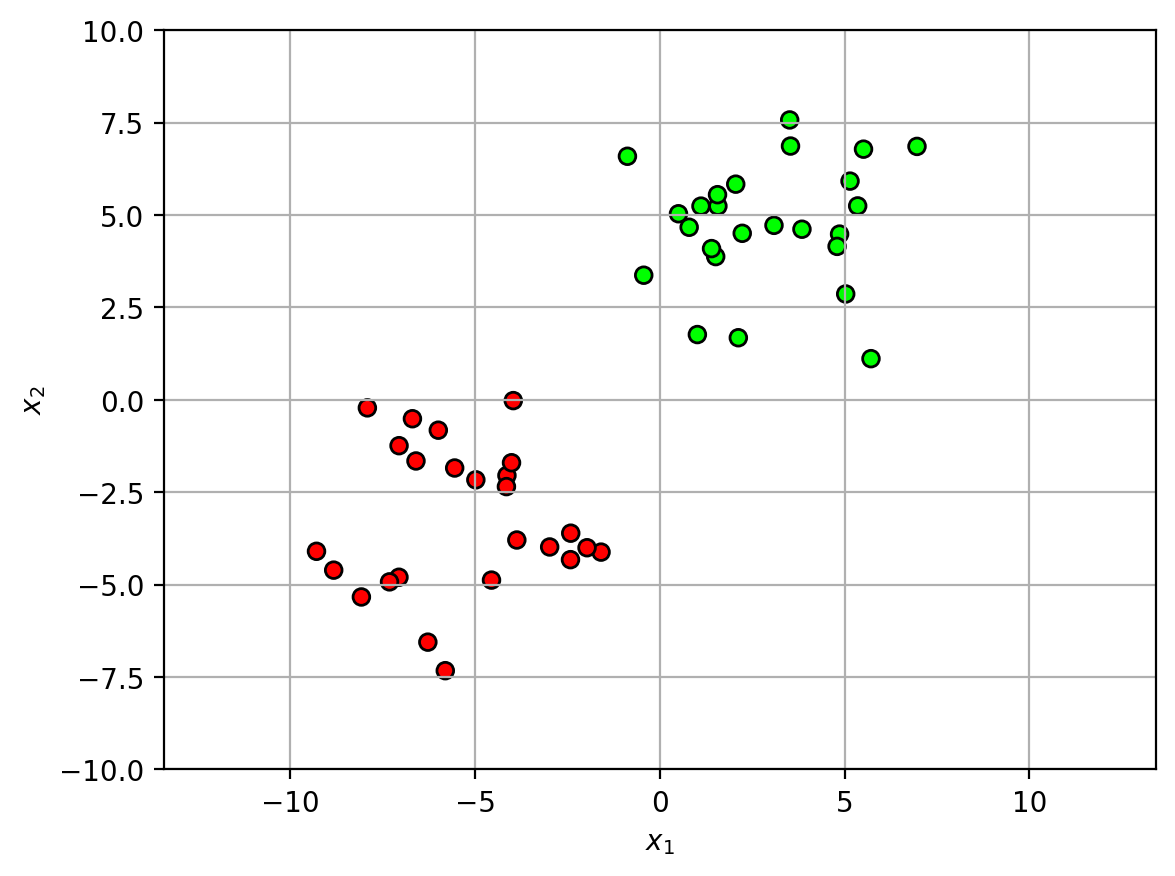

In [3]:
lsdatafig

# Which is the best separating line?
- there are many possible solutions...

In [4]:
def drawplane(w, b=None, c=None, wlabel=None, poscol=None, negcol=None, lw=2, ls='k-', label=None):
    # w^Tx + b = 0
    # w0 x0 + w1 x1 + b = 0
    # x1 = -w0/w1 x0 - b / w1

    # OR
    # w^T (x-c) = 0 = w^Tx - w^Tc  --> b = -w^Tc
    if c is not None:
        b = -sum(w*c)
    
    # the line
    if (abs(w[0])>abs(w[1])):   # vertical line
        x0 = array([-30,30])
        x1 = -w[0]/w[1] * x0 - b / w[1]
    else:                       # horizontal line
        x1 = array([-30,30])
        x0 = -w[1]/w[0] * x1 - b / w[0]
    
    # fill positive half-space or neg space
    #if (poscol):
    #    polyx = [x0[0], x0[-1], x0[-1], x0[0]]
    #    polyy = [x1[0], x1[-1], x1[0], x1[0]]
    #    plt.fill(polyx, polyy, poscol, alpha=0.2)
    # 
    #if (negcol):
    #    polyx = [x0[0], x0[-1], x0[0], x0[0]]
    #    polyy = [x1[0], x1[-1], x1[-1], x1[0]]
    #    plt.fill(polyx, polyy, negcol, alpha=0.2)

    if (poscol) or (negcol):
        polyx = [x0[0], x0[-1], x0[-1], x0[0]]
        polyy = [x1[0], x1[-1], x1[0], x1[0]]
        f = sum(w*[polyx[2], polyy[2]])+b
        if (f>0) and (poscol):
            plt.fill(polyx, polyy, poscol, alpha=0.2)
        if (f<0) and (negcol):
            plt.fill(polyx, polyy, negcol, alpha=0.2)
    
        polyx = [x0[0], x0[-1], x0[0], x0[0]]
        polyy = [x1[0], x1[-1], x1[-1], x1[0]]
        f = sum(w*[polyx[2], polyy[2]])+b
        if (f>0) and (poscol):
            plt.fill(polyx, polyy, poscol, alpha=0.2)
        if (f<0) and (negcol):
            plt.fill(polyx, polyy, negcol, alpha=0.2)

    # plot line
    plt.plot(x0, x1, ls, lw=lw, label=label)

    # the w
    if (wlabel):
        xp = array([0, -b/w[1]])
        xpw = xp+w
        plt.arrow(xp[0], xp[1], w[0], w[1], width=0.01)
        plt.text(xpw[0]-0.5, xpw[1], wlabel)

In [5]:
seplinefig = plt.figure()
ws = array([[1,0.1], [0.1,1], [1,1.5], [1.5,1]])
bs = array([0.9, -1, 2, 2.5])

for i in range(len(bs)):
    plt.subplot(2,2,i+1)
    plt.scatter(X[:,0], X[:,1], c=Y, cmap=mycmap, edgecolors='k')
    drawplane(ws[i,:], bs[i], poscol='g', negcol='r')
    plt.axis('equal'); plt.axis(axbox); plt.grid(True)
    plt.gca().xaxis.set_ticklabels([])
    plt.gca().yaxis.set_ticklabels([])    
    
plt.close()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


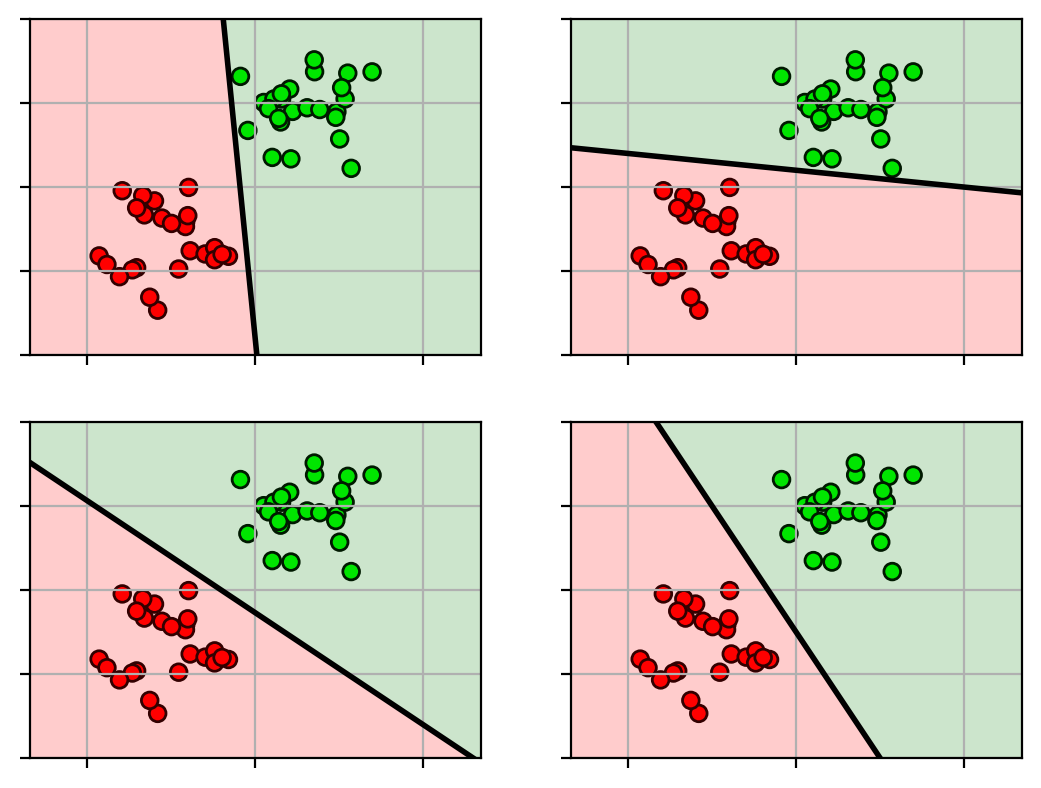

In [6]:
seplinefig

# Maximum margin
- Define the space between the separating line and the closest point as the _margin_.
  - think of this space as the "amount of wiggle room" for accommodating errors in estimating $\mathbf{w}$. 

In [7]:
def drawmargin(w,b,xmarg=None, label=None):
    wnorm = w / sqrt(sum(w**2))
    if xmarg is None:
        # calculate a point on the margin
        dm = 1 / sqrt(sum(w**2))
        xpt  = array([1,-w[0]/w[1]-b/w[1]])
        # then find the margin (assuming learned with SVM)
        xmarg = xpt + dm*wnorm
        xmarg2 = xpt - dm*wnorm
    else:
        # find the distance to the margin
        dm = (sum(w*xmarg)+b) / sqrt(sum(w**2))
        # move to the other side of the decision plane
        xmarg2 = xmarg - 2*dm*wnorm

    drawplane(w, c=xmarg, ls='k--', lw=1, label=label)
    drawplane(w, c=xmarg2, ls='k--', lw=1)

In [8]:
w = array([1.5,1])
b = 2.5

# calculate distance to margin
d = abs(dot(X,w.T) + b)
mmi = argmin(d)
x0 = X[mmi,:]

margfig = plt.figure()
plt.scatter(X[:,0], X[:,1], c=Y, cmap=mycmap, edgecolors='k')
drawplane(w, b, poscol='g', negcol='r', label='boundary')
plt.plot(x0[0], x0[1], 'ko', fillstyle='none', markeredgewidth=2)
drawmargin(w,b,x0, label='margin')
plt.axis('equal'); plt.axis(axbox); plt.grid(True)    
leg = plt.legend(loc='lower right' ,fontsize=10)
leg.get_frame().set_facecolor('white') 
plt.annotate(text='margin point', xy=x0, xytext=(-12.5,2.0), 
             arrowprops=dict(facecolor='black', width=2, shrink=0.1, headwidth=6))
plt.close()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


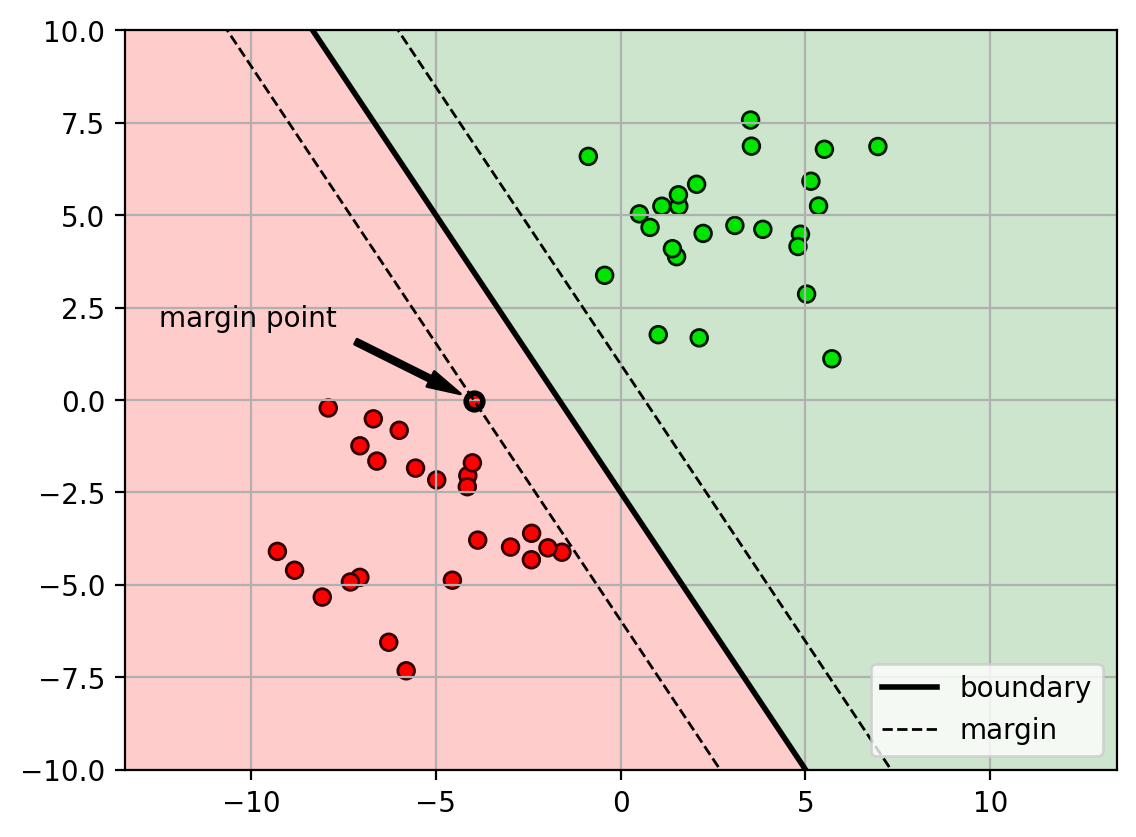

In [9]:
margfig

- **Idea:** the best separating line is the one that _maximizes the margin_.
  - i.e., puts the most distance between the closest points and the decision boundary.

In [10]:
margfigs = plt.figure()
for i in range(len(bs)):
    w = ws[i,:]
    b = bs[i]
    d = abs(dot(X,w.T) + b)
    mmi = argmin(d)
    x0 = X[mmi,:]

    plt.subplot(2,2,i+1)
    plt.scatter(X[:,0], X[:,1], c=Y, cmap=mycmap, edgecolors='k')
    drawplane(w, b, poscol='g', negcol='r')
    drawmargin(w, b, x0)
    plt.axis('equal'); plt.axis(axbox); plt.grid(True)
    
plt.close()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


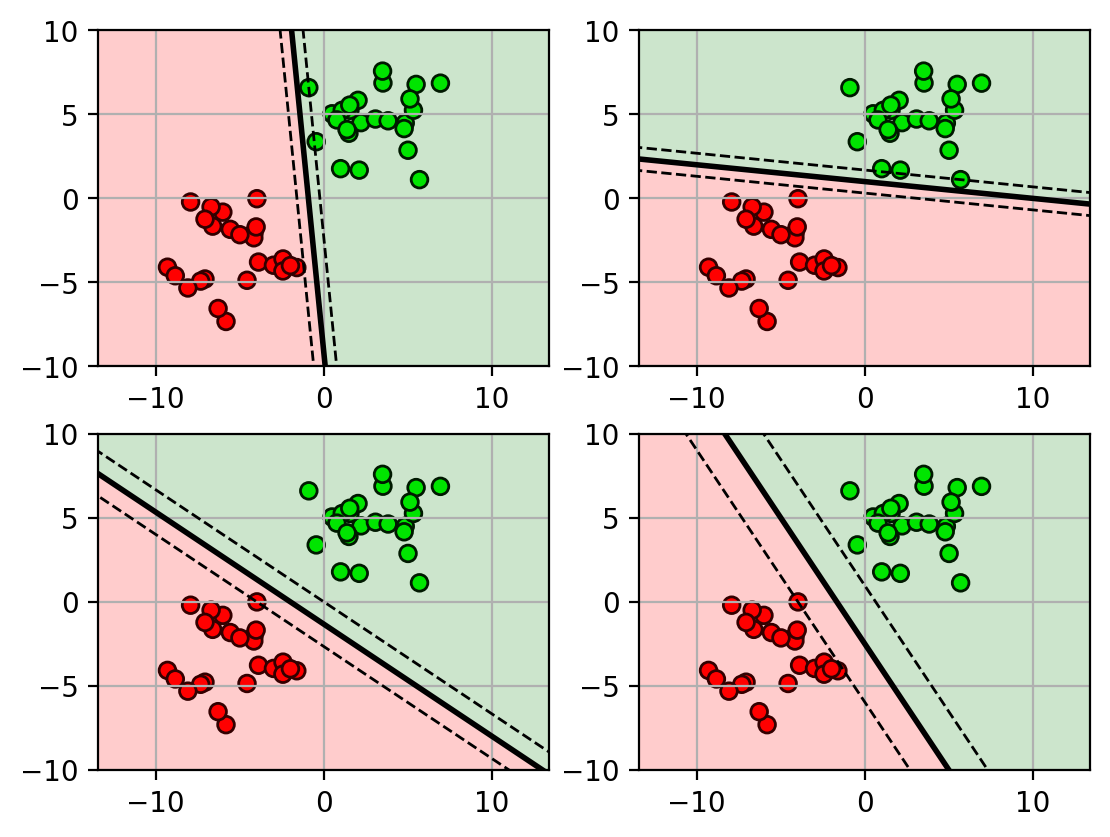

In [11]:
margfigs

- _the solution..._
  - by symmetry, there should be at least one margin point on each side of the boundary
    - if there is only one margin point, we could increase the margin distance by moving the boundary away from the margin point.
  - the points on the margins are called the **support vectors**
    - the points support (define) the margin

In [12]:
# fit SVM (kernel is the type of decision surface...more in the next lecture)
clf = svm.SVC(kernel='linear', C=inf)
clf.fit(X, Y)

def plot_svm(clf, axbox, mycmap, showleg=True):
    # get line parameters
    w = clf.coef_[0]
    b = clf.intercept_[0]

    drawplane(w, b, poscol='g', negcol='r', label='boundary')
    drawmargin(w, b, label='margin')
    plt.plot(clf.support_vectors_[:,0], clf.support_vectors_[:,1],
         'ko',fillstyle='none', markeredgewidth=2, label='support vectors')
    plt.grid(True); plt.axis('equal'); plt.axis(axbox);
    if showleg:
        leg = plt.legend(loc='lower right', fontsize=10)
        leg.get_frame().set_facecolor('white') 
        
    
maxmfig = plt.figure()
plot_svm(clf, axbox, mycmap)
plt.scatter(X[:,0], X[:,1], c=Y, cmap=mycmap, edgecolors='k')
plt.close()




Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


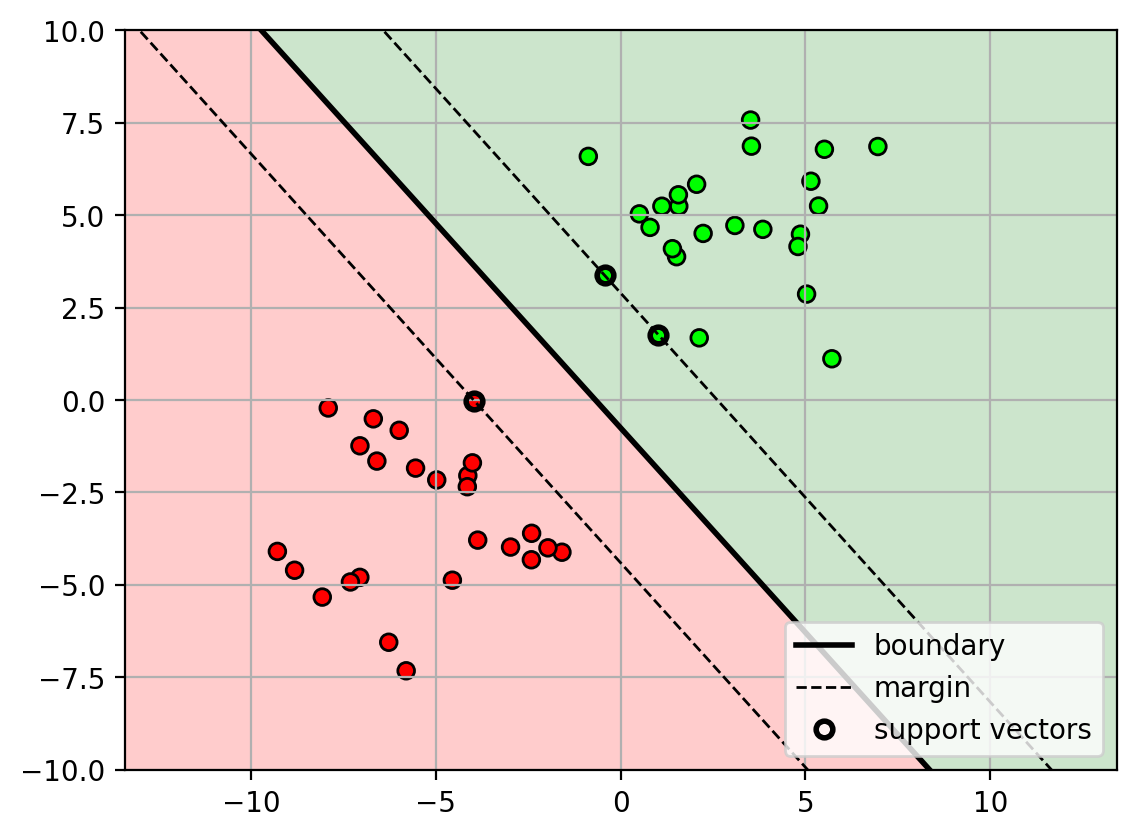

In [13]:
maxmfig

# Why is maximizing the margin good?
- the true $\mathbf{w}$ is uncertain
  - maximizing the margin allows the most uncertainty (wiggle room) for $\mathbf{w}$, while keeping all the points correctly classified.

In [14]:
maxmfigw = plt.figure()
plot_svm(clf, axbox, mycmap, showleg=False)
plt.scatter(X[:,0], X[:,1], c=Y, cmap=mycmap, edgecolors='k')

w = clf.coef_[0]
b = clf.intercept_[0]
for i in range(10):
    w2 = w + 0.05*random.standard_normal(w.shape)
    b2 = b + 0.2*random.standard_normal(b.shape)
    drawplane(w2, b2, lw=0.5, ls='b-')
plt.close()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


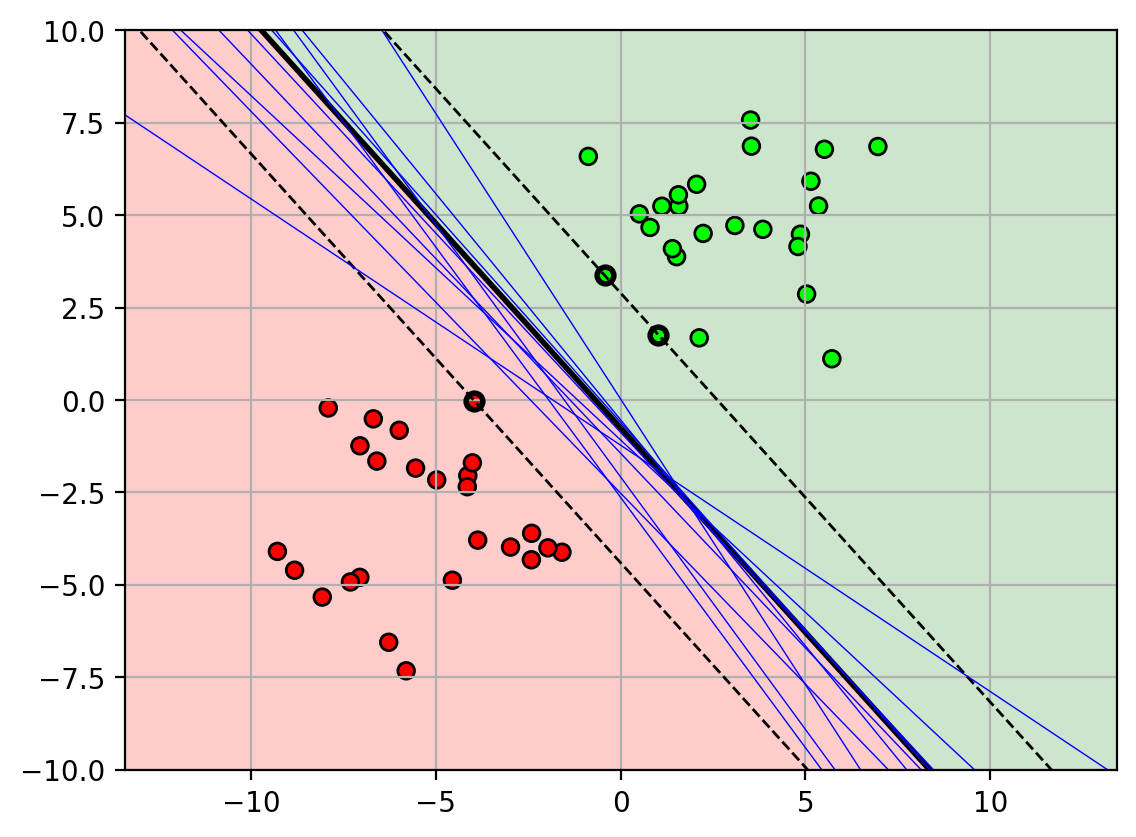

In [15]:
maxmfigw

- the data points are uncertain
  - maximizing the margin allows the most wiggle of the points, while keeping all the points correctly classified.

In [16]:
maxmfigp = plt.figure()
plot_svm(clf, axbox, mycmap)
plt.scatter(X[:,0], X[:,1], c=Y, cmap=mycmap, edgecolors='k')
plt.scatter(X[:,0], X[:,1], s=500, alpha=0.5, color='gray')
plt.close()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


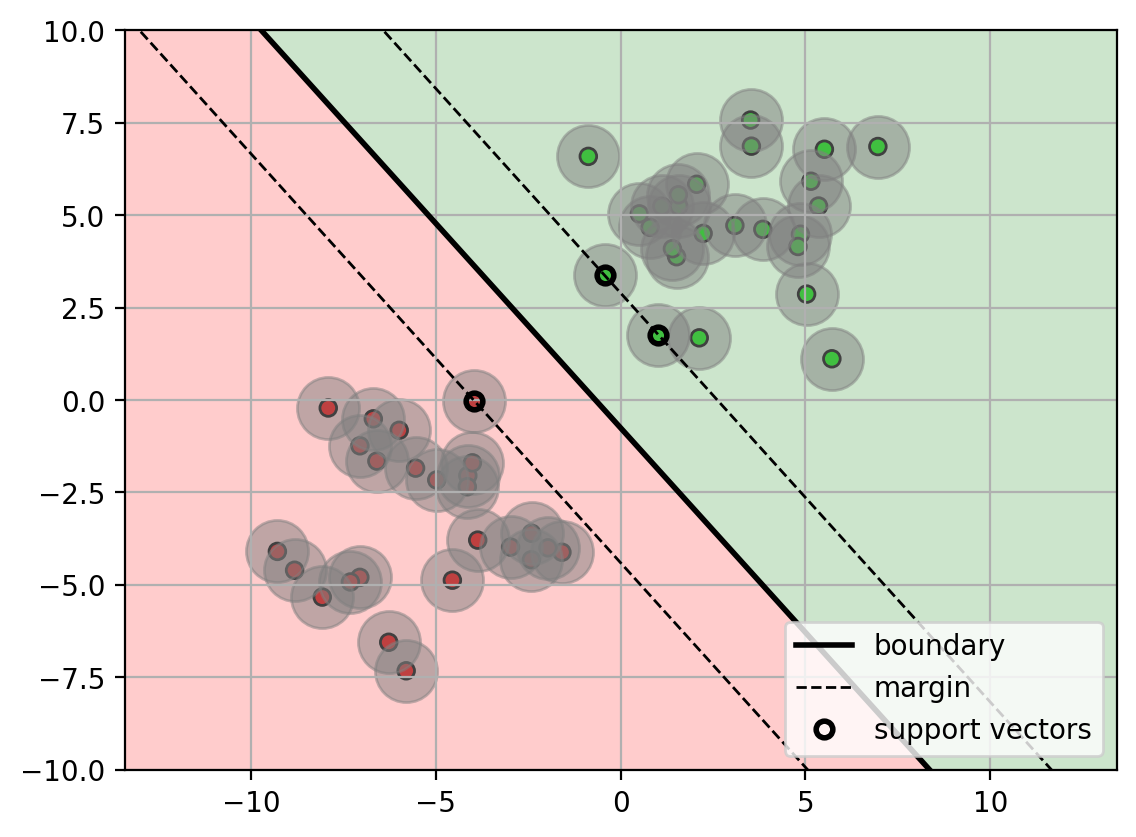

In [17]:
maxmfigp

# SVM Training
- Given a training set $\{\mathbf{x}_i,y_i\}_{i=1}^N$.
- First define the margin distance:
  - Distance from a point $\mathbf{x}_i$ to hyperplane $\mathbf{w}$: 
  $$d_i = \frac{|f(\mathbf{x}_i)|}{||\mathbf{w}||}$$
  - Margin distance is the minimum distance among all points: 
  $$\gamma = \min_i \frac{|f(\mathbf{x}_i)|}{||\mathbf{w}||}$$

In [18]:
def draw_dist(X, w, b, justmargin=False):
    wu = sqrt(w@w)
    d = (X@w + b) / wu
    Xo = w*d[:,newaxis] / wu
    Xp = X-Xo
    #plt.scatter(Xp[:,0], Xp[:,1])
    if not justmargin:
        for xp,x in zip(Xp,X):
            plt.plot([xp[0], x[0]], [xp[1], x[1]], ':b', lw=0.5)
    mm = amin(abs(d))
    for i,myd in enumerate(abs(d)):
        if abs(myd-mm) <= .001*mm:
            plt.plot([Xp[i,0], X[i,0]], [Xp[i,1],X[i,1]], 'b-', label="margin distance $\gamma$")
    #mmd = plt.plot([Xp[mmi,0], X[mmi,0]], [Xp[mmi,1],X[mmi,1]], 'b-', label="margin distance $\gamma$")
    

<>:13: SyntaxWarning: invalid escape sequence '\g'
<>:13: SyntaxWarning: invalid escape sequence '\g'
/var/folders/5h/9z8cfrvj02324js7fw73_cb00000gn/T/ipykernel_43322/3284564162.py:13: SyntaxWarning: invalid escape sequence '\g'
  plt.plot([Xp[i,0], X[i,0]], [Xp[i,1],X[i,1]], 'b-', label="margin distance $\gamma$")


In [19]:
dfig = plt.figure()
w = ws[3,:]
b = bs[3]
d = abs(dot(X,w.T) + b)
mmi = argmin(d)
x0 = X[mmi,:]

plt.scatter(X[:,0], X[:,1], c=Y, cmap=mycmap, edgecolors='k')
drawplane(w, b, poscol='g', negcol='r')
drawmargin(w, b, x0)
draw_dist(X, w, b)
plt.grid(True)
plt.axis('equal')
plt.axis(axbox);
plt.legend()
    
plt.close()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


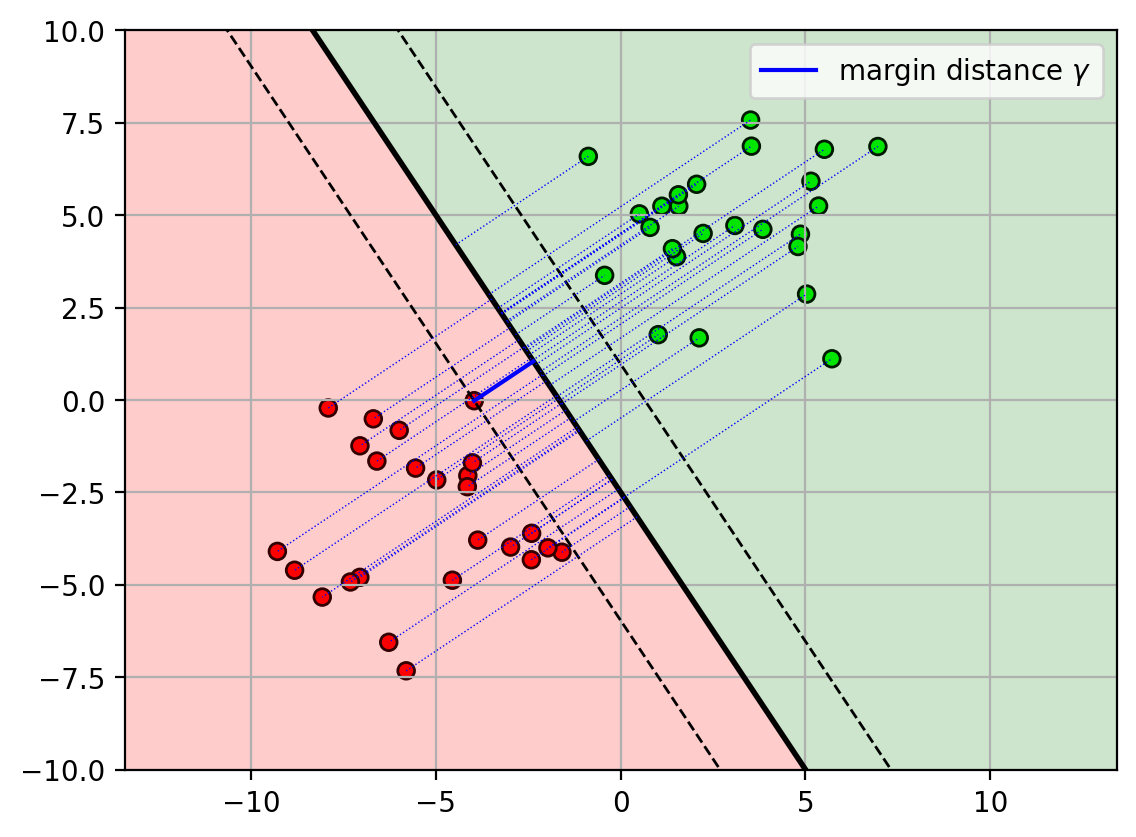

In [20]:
dfig

- The hyperplane $\mathbf{w}$ appears in both numerator and denominator! 
  - $\gamma =  \min_i \frac{|f(\mathbf{x}_i)|}{||\mathbf{w}||}= \min_i \frac{|\mathbf{w}^T\mathbf{x}_i+b|}{||\mathbf{w}||}$
- Changing the length of $\mathbf{w}$ won't affect the margin distance.
  - $\hat{\mathbf{w}} = a\mathbf{w}$, $\hat{b} = ab$
  - $ \frac{|\hat{\mathbf{w}}^T\mathbf{x}_i+\hat{b}|}{||\hat{\mathbf{w}}||} = \frac{|a\mathbf{w}^T\mathbf{x}_i+ab|}{||a\mathbf{w}||} = \frac{|\mathbf{w}^T\mathbf{x}_i+b|}{||\mathbf{w}||}$
- Margin distance is determined by the direction of $\mathbf{w}$, not the length.

# Normalization
- Since the length of $\mathbf{w}$ doesn't matter, we can assume a normalization for $\mathbf{w}$.
- Two possibilities:
  1. set denominator to 1: $||\mathbf{w}|| = 1$
    - $||\mathbf{w}||$ is a unit-norm vector
  2. set numerator to 1: $\min_i |f(\mathbf{x}_i)|=1$
    - the point $\mathbf{x}_i$ on the margin has $f(\mathbf{x}_i)=1$.
- Which is better?

# SVM Optimization Problem
- Choose the 2nd option.
  - constraint: $\min_i |f(\mathbf{x}_i)|=1$
  - margin: $\gamma = \frac{1}{||\mathbf{w}||}$
- Maximize the margin:
  $$ (\hat{\mathbf{w}},b) = \mathop{\mathrm{argmax}}_{\mathbf{w},b} \frac{1}{||\mathbf{w}||} \quad \text{s.t.}\   \min_i |f(\mathbf{x}_i)|=1 $$
- Invert the objective to turn into a minimization problem
  $$ (\hat{\mathbf{w}},b) = \mathop{\mathrm{argmin}}_{\mathbf{w},b} \frac{1}{2}||\mathbf{w}||^2 \quad \text{s.t.}\   \min_i |f(\mathbf{x}_i)|=1 $$

- Note: if the points are correctly classified...
  - for points in class $y_i=1$, then $f(\mathbf{x}_i) > 0$ .
  - for points in class $y_i=-1$, then $f(\mathbf{x}_i) < 0$.
- Thus, the constraint: $\min_i |f(\mathbf{x}_i)| = 1,$
  - can be rewritten: $\min_i y_i f(\mathbf{x}_i) = 1$

- Closer look: 
  - original constraint: $\min_i y_if(\mathbf{x}_i)=1$
    - the minimum over all $i$ is 1.
  - equivalent constraint: $y_if(\mathbf{x}_i) \geq 1, \forall i$
    - suppose $y_if(\mathbf{x}_i) = y_i(\mathbf{w}^T\mathbf{x}_i+b)  > 1, \forall i$.
    - since we are minimizing $||\mathbf{w}||$, $\mathbf{w}$ will shrink so that at least one  $\mathbf{x}_i$ will have $y_if(\mathbf{x}_i) = 1$.
      - $(\mathbf{w},b) \Rightarrow (\delta\mathbf{w},\delta b)$, where $y_i(\delta\mathbf{w}^T\mathbf{x}_i+\delta b)  \geq 1, \forall i$


# SVM Training Objective
- given a training set $\{\mathbf{x}_i,y_i\}_{i=1}^N$, optimize:
  $$ \begin{aligned}\mathop{\mathrm{argmin}}_{\mathbf{w},b} &\frac{1}{2} \mathbf{w}^T\mathbf{w}\\\mathrm{s.t.}~&y_i f(\mathbf{x}_i)\geq 1,\quad \forall i\end{aligned}$$
  - the objective minimizes the inverse of the margin distance, i.e., maximizes the margin.
  - the inequality constraints ensure that all points are either on or outside of the margin.
    - a point on the margin has $y_if(\mathbf{x}_i)=1$. 
    - also written as $y_i (\mathbf{w}^T\mathbf{x}_i+b) \geq 1$.

# Review of Constrained Optimization
- Consider an optimization problem with inequality constraints:
$$ \min_{\mathbf{x}} f(\mathbf{x})\ \text{s.t.}\  g(\mathbf{x}) \geq 0$$
  - $f(\mathbf{x})$ is the objective function (for SVM, it's the inverse margin).
  - $g(\mathbf{x})$ is the constraint function (for SVM, it's the margin constraint).
  
<center>
<img width="500" src="imgs/fmin.png"></center>

- Use Langrange multipliers to solve this problem:
  - introduce Lagrange multiplier: $\lambda \geq 0$
  - form the Lagrangian: $L(\mathbf{x},\lambda) = f(\mathbf{x}) - \lambda g(\mathbf{x})$
  - find the stationary point $(\mathbf{x}^*, \lambda^*)$ of the Lagrangian
    - find solution of $\frac{dL}{d\mathbf{x}}=0$ and $\frac{dL}{d\lambda}=0$.
  - at the solution, the Langrange multiplier indicates the mode of the inequality constraint
    - when $\lambda^*>0$, then $g(\mathbf{x}^*)=0$ (called "active equality").
    - when $\lambda^*=0$, then $g(\mathbf{x}^*)>0$ (called "inactive").

# Duality
- We can rewrite the original (primal) problem into its dual form:
  - dual function: $q(\lambda) = \min_{\mathbf{x}} L(\mathbf{x},\lambda)$
  - dual problem: $\max_{\lambda\geq 0} q(\lambda)$
- Solve for $\lambda$, rather than original variable $\mathbf{x}$.
  - can recover the value of $\mathbf{x}$ from $\lambda$.

- If the optimization problem is convex...
  - solving the dual is equivalent to solving the **primal**
  - $\min_{\mathbf{x}, g(\mathbf{x})\geq 0} f(\mathbf{x}) = \max_{\lambda\geq 0} q(\lambda)$.
- **Note:** The SVM problem is convex, so we can obtain an equivalent dual problem.

# Lagrange multipliers & SVM
- introduce a Langrange multiplier $\alpha_i$ for each constrain
    $$ L(\mathbf{w}, \alpha) =  \frac{1}{2} \mathbf{w}^T\mathbf{w}- \sum_i \alpha_i [y_i(\mathbf{w}^T\mathbf{x}_i+b)-1] $$
- Lagrange multiplier tells us which points are on the margin:
  - If $\alpha_i=0$, then $y_i(\mathbf{w}^T\mathbf{x}_i+b)>1$ ($\mathbf{x}_i$ is beyond margin).
  - If $\alpha_i>0$, then $y_i(\mathbf{w}^T\mathbf{x}_i+b)=1$ ($\mathbf{x}_i$ is on the margin).
    - i.e., the point is a *support vector*.

# SVM Dual Problem
- The SVM problem can be rewritten as a _dual_ problem:
$$\mathop{\mathrm{argmax}}_{\alpha} \sum_i \alpha_i -\frac{1}{2}\sum_{i=1}^N\sum_{j=1}^N \alpha_i\alpha_j y_i y_j \mathbf{x}_i^T \mathbf{x}_j \\~~ \mathrm{s.t.} \sum_{i=1}^N \alpha_iy_i = 0, \quad \alpha_i\geq 0$$
- The new variable $\alpha_i$ corresponds to each training sample $(\mathbf{x}_i,y_i)$.
  - instead of solving for $\mathbf{w}$, we now solve for $\mathbf{\alpha}$

- Recover the hyperplane $\mathbf{w}$ using $\alpha$:
  - weighted combination of (transformed) data points.
  - $\mathbf{w} = \sum_{i=1}^N \alpha_i y_i \mathbf{x}_i$
- Classify a new point $\mathbf{x}_*$,  
  $$\begin{align}y_* &= \mathrm{sign}(\mathbf{w}^T \mathbf{x}_*+b) \\&= \mathrm{sign}(\sum_{i=1}^N \alpha_i y_i \mathbf{x}_i^T \mathbf{x}_* + b)\end{align}$$

- Interpretation of $\alpha_i$
  - $\alpha_i=0$ when the sample $\mathbf{x}_i$ is not on the margin.
  - $\alpha_i>0$ when the sample $\mathbf{x}_i$ is on the margin (or violates).
    - i.e., the sample $\mathbf{x}_i$ is a support vector.
    - $y_i\alpha_i > 0$ margin sample for positive class
    - $y_i\alpha_i < 0$ margin sample for negative class.

# SVM Prediction
- given a new data point $\mathbf{x}_*$, use sign of linear function to predict class
    - $y_* = \mathop{\mathrm{sign}} f(\mathbf{x}_*) = \mathop{\mathrm{sign}}(\mathbf{w}^T \mathbf{x}_* + b)$

# Example
- Regions defined by $f(\mathbf{x})$:
  - $f(\mathbf{x})=0$ -- decision boundary
  - $f(\mathbf{x})=\pm1$ -- positive and negative margins
  - $f(\mathbf{x})>1$ -- points correctly classified as class 1
  - $f(\mathbf{x})<-1$ -- points correctly classified as class -1


In [21]:
# fit SVM (kernel is the type of decision surface...more in the next lecture)
clf = svm.SVC(kernel='linear', C=inf)
clf.fit(X, Y)

egsvmfig = plt.figure()
plot_svm(clf, axbox, mycmap)
plt.scatter(X[:,0], X[:,1], c=Y, cmap=mycmap, edgecolors='k')
draw_dist(X, clf.coef_[0], clf.intercept_[0], justmargin=True)
plt.text(-9.5,7.5, '$f(\mathbf{x})=0$', fontsize=9, bbox=dict(facecolor='white', alpha=0.8, edgecolor='white'))
plt.text(-5,7.5, '$f(\mathbf{x})=1$', fontsize=9, bbox=dict(facecolor='white', alpha=0.8, edgecolor='white'))
plt.text(-12,5, '$f(\mathbf{x})=-1$', fontsize=9, bbox=dict(facecolor='white', alpha=0.8, edgecolor='white'))
plt.text(7,5, '$f(\mathbf{x})>1$', fontsize=9, bbox=dict(facecolor='white', alpha=0.8, edgecolor='white'))
plt.text(-12,-2.5, '$f(\mathbf{x})<-1$', fontsize=9, bbox=dict(facecolor='white', alpha=0.8, edgecolor='white'))
plt.annotate(text='$\gamma = 1/||\mathbf{w}||$', xy=(0,1), xytext=(2.5,-2.0), 
             backgroundcolor='white', 
             arrowprops=dict(facecolor='black', width=1, shrink=0.1, headwidth=6))
plt.close()

<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\g'
<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\g'
/var/folders/5h/9z8cfrvj02324js7fw73_cb00000gn/T/ipykernel_43322/2869223478.py:9: SyntaxWarning: invalid escape sequence '\m'
  plt.text(-9.5,7.5, '$f(\mathbf{x})=0$', fontsize=9, bbox=dict(facecolor='white', alpha=0.8, edgecolor='white'))
/var/folders/5h/9z8cfrvj02324js7fw73_cb00000gn/T/ipykernel_43322/2869223478.py:10: SyntaxWarning: invalid escape sequence '\m'
  plt.text(-5,7.5, '$f(

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


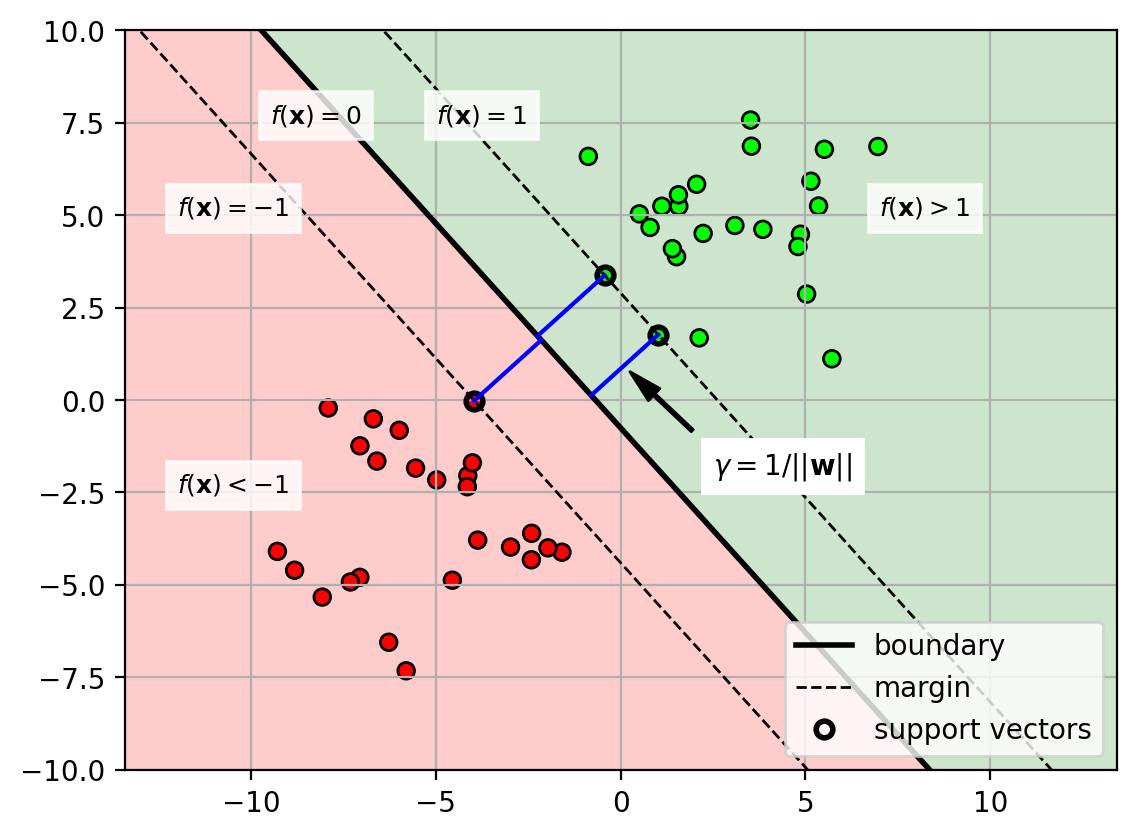

In [22]:
egsvmfig

# What about non-separable data?
- use the same linear classifier
  - allow some training samples to **violate** the margin
    - i.e., are inside the margin (or even mis-classified)

- Define "slack" variable $\xi_i \geq 0$
  - $\xi_i=0$ means sample is outside of margin area (no slack)
  - $\xi_i>0$ means sample is inside of margin area (slack)

In [23]:
slackfig = plt.figure(figsize=(5,5))
plot_svm(clf, axbox, mycmap, showleg=False)
plt.scatter(X[:,0], X[:,1], c=Y, cmap=mycmap, edgecolors='k')

xv = array([0.5, -2])
xm = xv-clf.coef_.ravel()*5.2

plt.scatter([xv[0]], [xv[1]], c=[1], cmap=mycmap, edgecolors='k')
# slack point
plt.annotate(text='violates margin', xy=xv, xytext=(4.0,-2.0), 
             backgroundcolor='white', 
             arrowprops=dict(facecolor='black', width=1, shrink=0.1, headwidth=6))

plt.annotate(text="", xy=xv, xytext=xm, 
            arrowprops=dict(arrowstyle="<->"))
plt.text(-0.2, -3.5, "$\\xi_i>0$", fontsize=12)
plt.text(-5, -7, "$\\xi_i=0$", fontsize=14)
plt.close()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


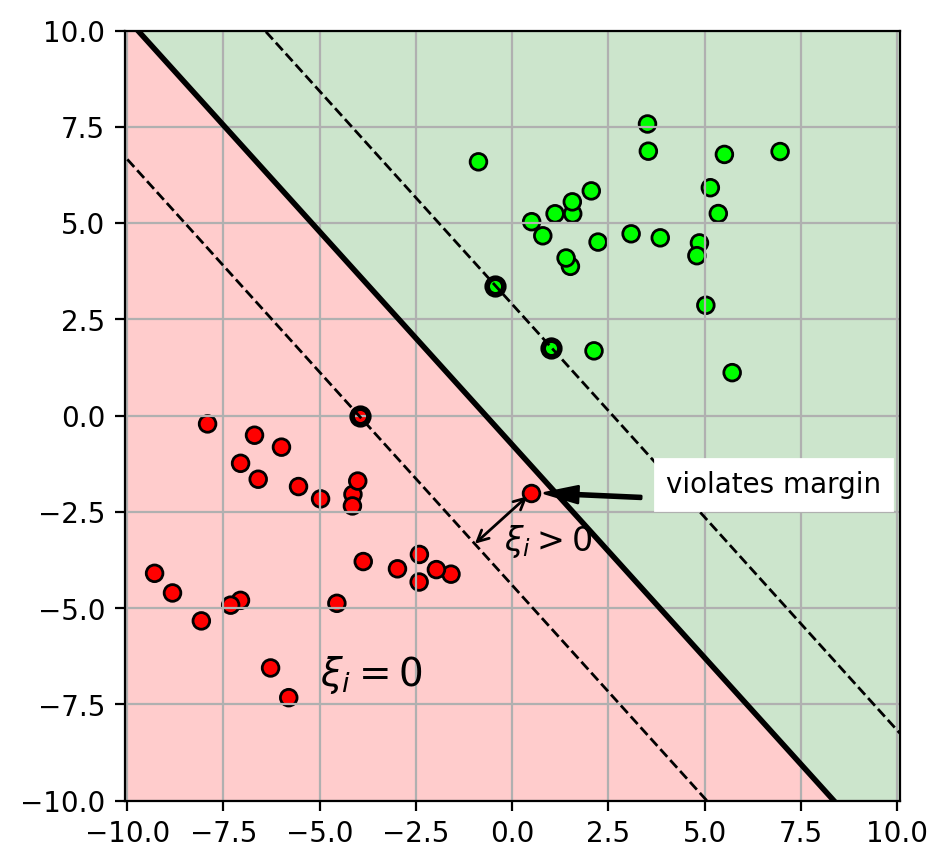

In [24]:
slackfig

- constraint now includes slack variable 
  - $y_i f(\mathbf{x}_i)\geq 1-\xi_i,\forall i$
- Two possibilities:
  - $\xi_i=0$, then sample $\mathbf{x}_i$ has normal margin constraint: $y_i f(\mathbf{x}_i)\geq 1$
  - $\xi_i>0$, then sample $\mathbf{x}_i$ is inside margin: $y_i f(\mathbf{x}_i) = 1-\xi_i$
    - Note that: $y_i f(\mathbf{x}_i) < 1$, inside margin.

# Soft-SVM optimization problem
- Penalize each training sample that violates the margin by summing over $\xi_i$.
  - penalty controlled by hyperparameter $C$.
    - smaller value means allow more violations (less penalty)
    - larger value means don't allow violations (more penalty)

$$\begin{aligned}\mathop{\mathrm{argmin}}_{\mathbf{w},b} &\frac{1}{2} \mathbf{w}^T\mathbf{w} + C\sum_{i=1}^N \xi_i \\\mathrm{s.t.}~&y_if(\mathbf{x}_i)\geq 1-\xi_i,\quad \forall i\\&\xi_i\geq 0\end{aligned}$$

In [25]:
# generate non-separable random data
X,Y = datasets.make_blobs(n_samples=50, 
         centers=2, cluster_std=3.5, n_features=2, 
         center_box=(-5,5), random_state=4487)

Cs = [0.01, 0.1, 1, 10]
Cmargfigs = plt.figure()

for i in range(len(Cs)):
    # fit SVM
    clf = svm.SVC(kernel='linear', C=Cs[i])
    clf.fit(X, Y)

    plt.subplot(2,2,i+1)
    plt.scatter(X[:,0], X[:,1], c=Y, cmap=mycmap, edgecolors='k')
    plot_svm(clf, axbox, mycmap, showleg=False)
    plt.gca().xaxis.set_ticklabels([])
    plt.gca().yaxis.set_ticklabels([])
    plt.title("C="+str(Cs[i]))
    
plt.close()

- Example with different $C$.

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


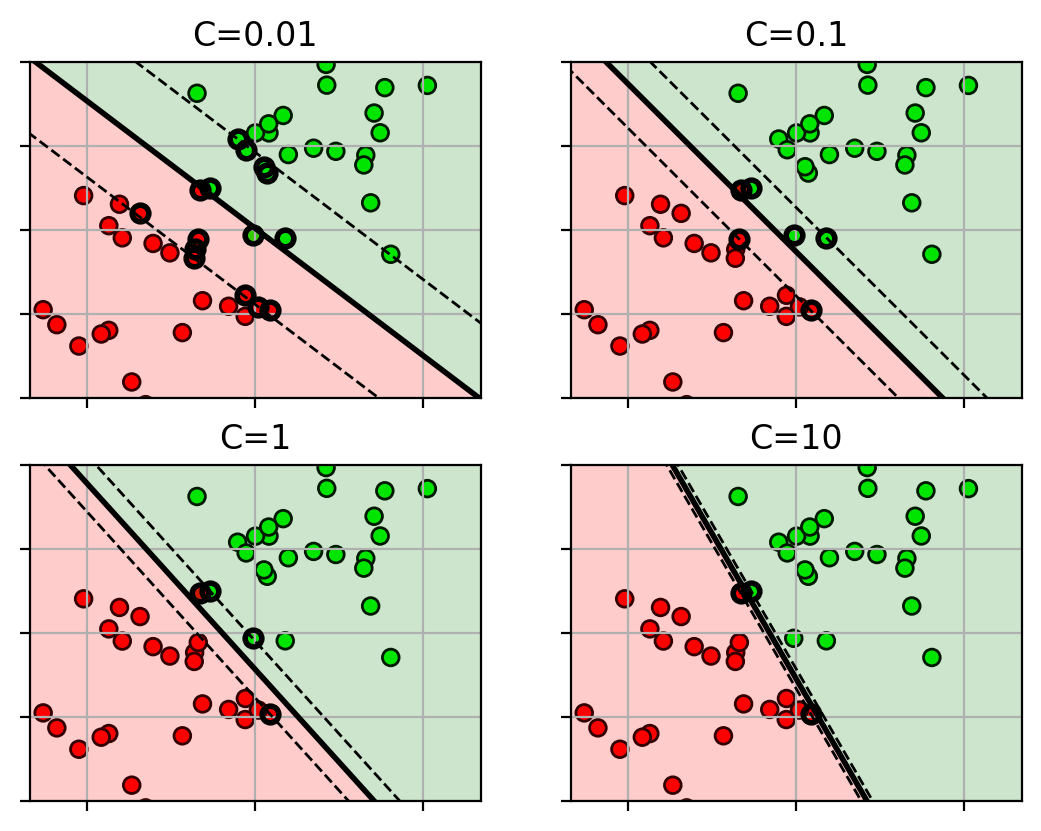

In [26]:
Cmargfigs

# Loss function
- After some massaging, the objective function is:
$$ \mathop{\mathrm{argmin}}_{\mathbf{w},b} \frac{1}{C} \mathbf{w}^T\mathbf{w} + \sum_{i=1}^N \max(0, 1-y_i f(\mathbf{x}_i))$$
  - hinge loss function: $L(z_i) = \max(0,1-z_i)$
    - Note: $\max(a,b)$ returns whichever value ($a$ or $b$) is largest.

In [27]:
z = linspace(-6,6,100)
logloss = log(1+exp(-z))
hingeloss = maximum(0, 1-z)
lossfig = plt.figure()
plt.plot(z,hingeloss, 'b-')

plt.plot([0,0], [0,9], 'k--')
plt.text(0,8.5, "incorrectly classified $\\Leftarrow$ ", ha='right', weight='bold')
plt.text(0,8.5, " $\Rightarrow$ correctly classified", ha='left', weight='bold')

plt.annotate(text="large loss for badly\nmisclassified samples", 
             xy=(-4,5), xytext=(-4.5,6.2),backgroundcolor='white',
            arrowprops=dict(arrowstyle="->"))
plt.annotate(text="non-zero loss\nfor samples\nnear margin", 
             xy=(0.5,0.5), xytext=(-0.5,3.2), backgroundcolor='white',
            arrowprops=dict(arrowstyle="->"))
plt.annotate(text="zero loss for\nsamples on correct\nside of margin", 
             xy=(3,0.0), xytext=(2,1.1), backgroundcolor='white',
            arrowprops=dict(arrowstyle="->"))
plt.grid(True)
plt.xlabel('$z_i$');
plt.ylabel('loss')
plt.title('hinge loss')
plt.xlim(-6,6)
plt.close()

<>:9: SyntaxWarning: invalid escape sequence '\R'
<>:9: SyntaxWarning: invalid escape sequence '\R'
/var/folders/5h/9z8cfrvj02324js7fw73_cb00000gn/T/ipykernel_43322/370200353.py:9: SyntaxWarning: invalid escape sequence '\R'
  plt.text(0,8.5, " $\Rightarrow$ correctly classified", ha='left', weight='bold')


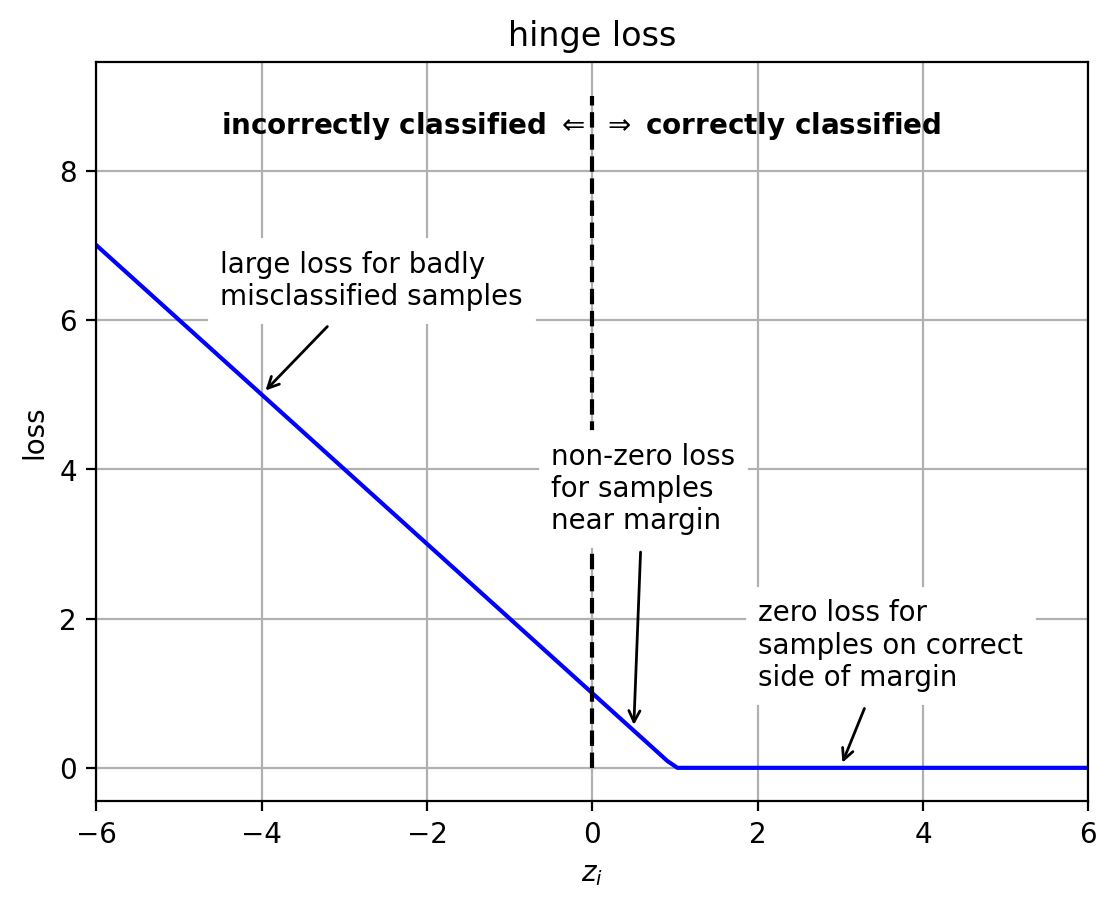

In [28]:
lossfig

# Example: Iris Data

In [29]:
# load iris data each row is (petal length, sepal width, class)
irisdata = loadtxt('iris2.csv', delimiter=',', skiprows=1)

X = irisdata[:,0:2]  # the first two columns are features (petal length, sepal width)
Y = irisdata[:,2]    # the third column is the class label (versicolor=1, virginica=2)

print(X.shape)

(100, 2)


In [30]:
# randomly split data into 50% train and 50% test set
trainX, testX, trainY, testY = \
  model_selection.train_test_split(X, Y, 
  train_size=0.5, test_size=0.5, random_state=4487)

print(trainX.shape)
print(testX.shape)

(50, 2)
(50, 2)


In [31]:
# fit the SVM using all the data and the best C   
clf = svm.SVC(kernel='linear', C=2)
clf.fit(trainX, trainY)

# get line parameters
w = clf.coef_[0]
b = clf.intercept_[0]
print(w)
print(b)

[2.87200943 0.10399865]
-13.95923965217775


In [32]:
# indices of data points that are support vectors (on or inside the margin)
clf.support_

array([ 0,  7, 12, 31, 36, 41, 13, 20, 22, 25, 33, 46], dtype=int32)

In [33]:
axbox = [2.5, 7, 1.5, 4]
svmfig = plt.figure()
plot_svm(clf, axbox, mycmap)
plt.scatter(trainX[:,0], trainX[:,1], c=trainY, cmap=mycmap, edgecolors='k')
plt.xlabel('petal length'); plt.ylabel('sepal width')
plt.title('class boundary with training data');
plt.close()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


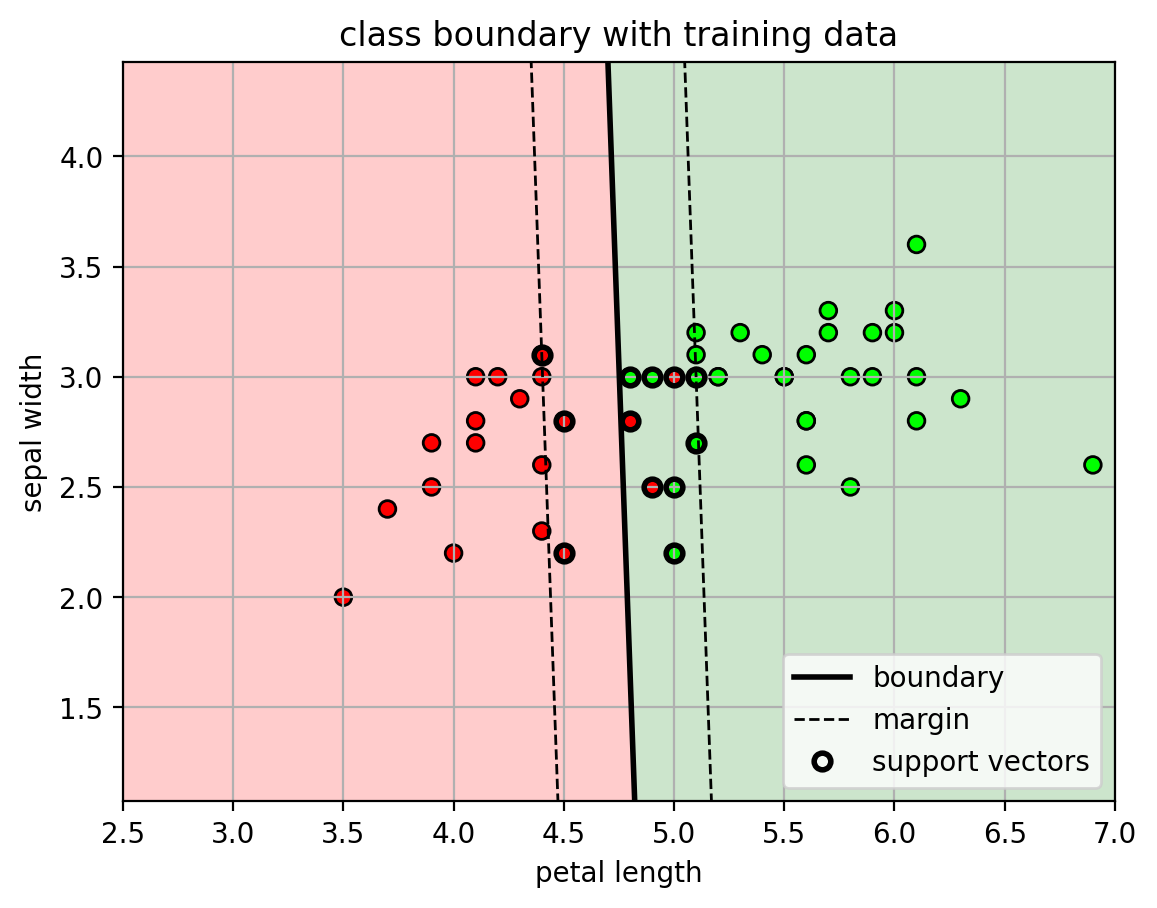

In [34]:
svmfig

- SVM doesn't have it's own dedicated cross-validation function
- Use the `GridSearchCV` to run cross-validation for a list of parameters
  - calculate average accuracy for each parameter
  - select parameter with average highest accuracy, retrain model with all data
  - Speed up: each parameter can be trained/tested separately, specify number of parallel jobs using `n_jobs`

In [35]:
# setup the list of parameters to try
paramgrid = {'C': logspace(-3,3,13)}
print(paramgrid)

# setup the cross-validation object
# pass the SVM object, parameter grid, and number of CV folds
# set number of parallel jobs to -1 (use all cores)
svmcv = model_selection.GridSearchCV(svm.SVC(kernel='linear'), paramgrid, cv=5,
                                     n_jobs=-1, verbose=True)

# run cross-validation (train for each split)
svmcv.fit(trainX, trainY);

{'C': array([1.00000000e-03, 3.16227766e-03, 1.00000000e-02, 3.16227766e-02,
       1.00000000e-01, 3.16227766e-01, 1.00000000e+00, 3.16227766e+00,
       1.00000000e+01, 3.16227766e+01, 1.00000000e+02, 3.16227766e+02,
       1.00000000e+03])}
Fitting 5 folds for each of 13 candidates, totalling 65 fits


In [36]:
# show the test error for each parameter set
for m,p in zip(svmcv.cv_results_['mean_test_score'], svmcv.cv_results_['params']):
    print("mean={:.4f} {}".format(m,p))

mean=0.6200 {'C': np.float64(0.001)}
mean=0.6200 {'C': np.float64(0.0031622776601683794)}
mean=0.6200 {'C': np.float64(0.01)}
mean=0.6600 {'C': np.float64(0.03162277660168379)}
mean=0.9400 {'C': np.float64(0.1)}
mean=0.9600 {'C': np.float64(0.31622776601683794)}
mean=0.9400 {'C': np.float64(1.0)}
mean=0.9400 {'C': np.float64(3.1622776601683795)}
mean=0.9400 {'C': np.float64(10.0)}
mean=0.9200 {'C': np.float64(31.622776601683793)}
mean=0.9000 {'C': np.float64(100.0)}
mean=0.9000 {'C': np.float64(316.22776601683796)}
mean=0.9000 {'C': np.float64(1000.0)}


{'C': np.float64(0.31622776601683794)}
0.96
SVC(C=np.float64(0.31622776601683794), kernel='linear')


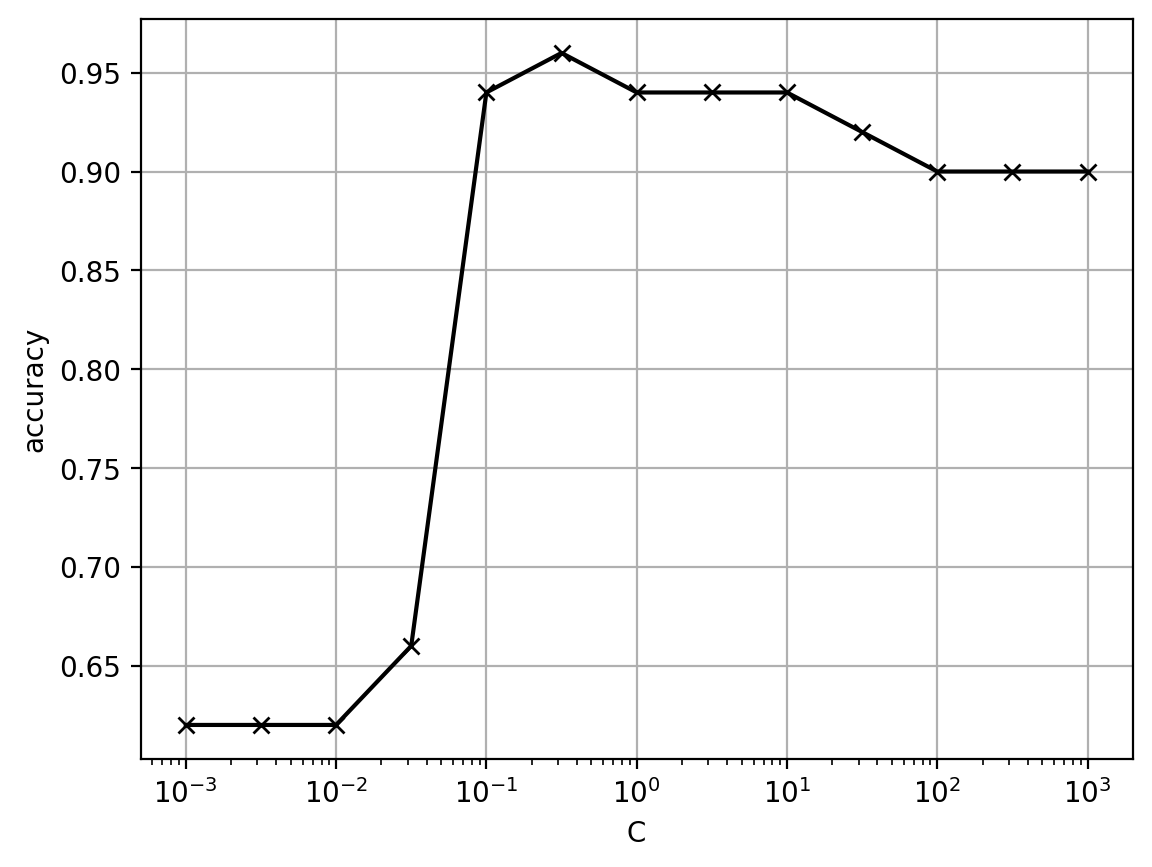

In [37]:
# make a plot
allC      = [p['C'] for p in svmcv.cv_results_['params']]
allscores = svmcv.cv_results_['mean_test_score']
    
plt.figure()
plt.semilogx(allC, allscores, 'kx-')
plt.xlabel('C'); plt.ylabel('accuracy')
plt.grid(True)

# view best results and best retrained estimator
print(svmcv.best_params_)
print(svmcv.best_score_)
print(svmcv.best_estimator_)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


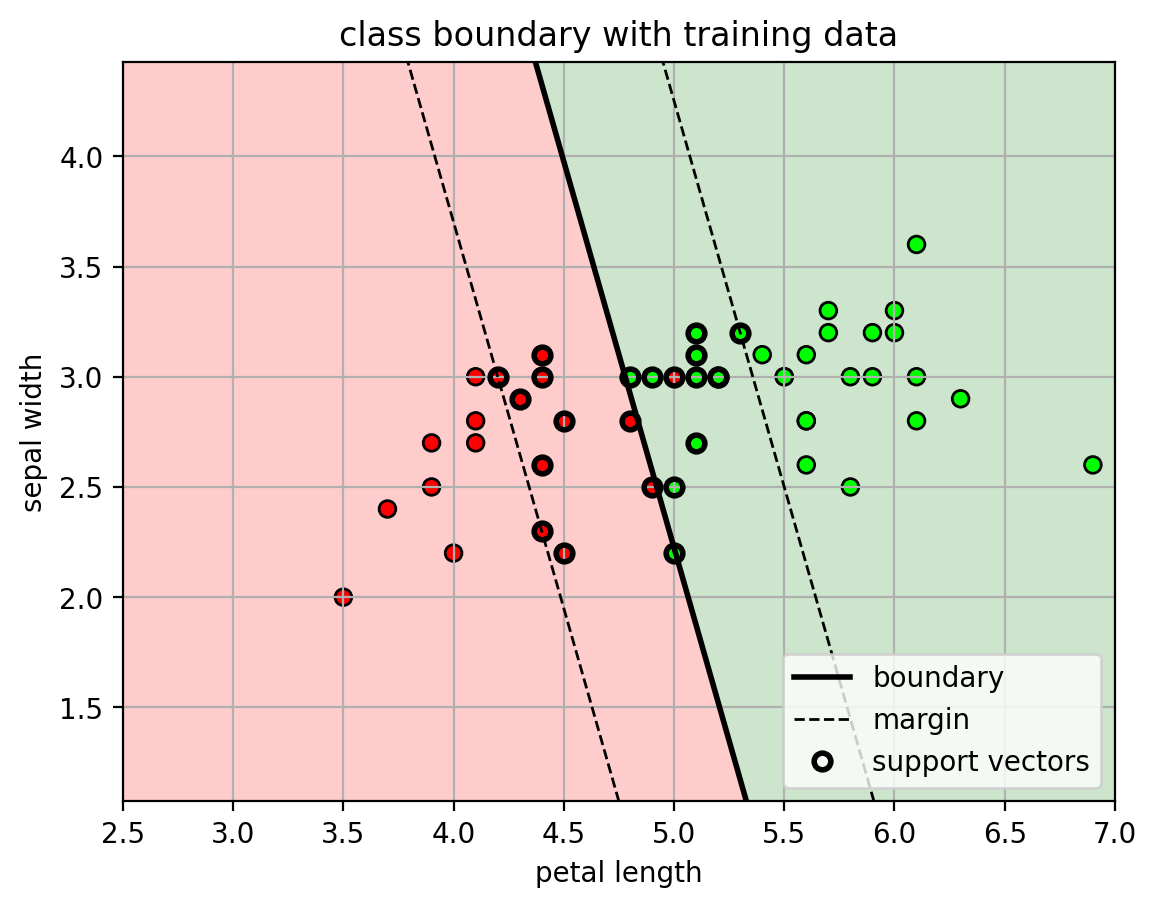

In [38]:
plt.figure()
plot_svm(svmcv.best_estimator_, axbox, mycmap)
plt.scatter(trainX[:,0], trainX[:,1], c=trainY, cmap=mycmap, edgecolors='k')
plt.xlabel('petal length'); plt.ylabel('sepal width')
plt.title('class boundary with training data');

In [39]:
# Directly use svmcv to make predictions
predY = svmcv.predict(testX)

acc = metrics.accuracy_score(testY, predY)
print("test accuracy = " + str(acc))

test accuracy = 0.88


In [40]:
# Plot test data
tsvmfig = plt.figure()
plot_svm(svmcv.best_estimator_, axbox, mycmap)
plt.scatter(testX[:,0], testX[:,1], c=testY, cmap=mycmap, marker='s', edgecolors='k')
plt.xlabel('petal length'); plt.ylabel('sepal width')
plt.title('class boundary with testing data');
plt.close()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


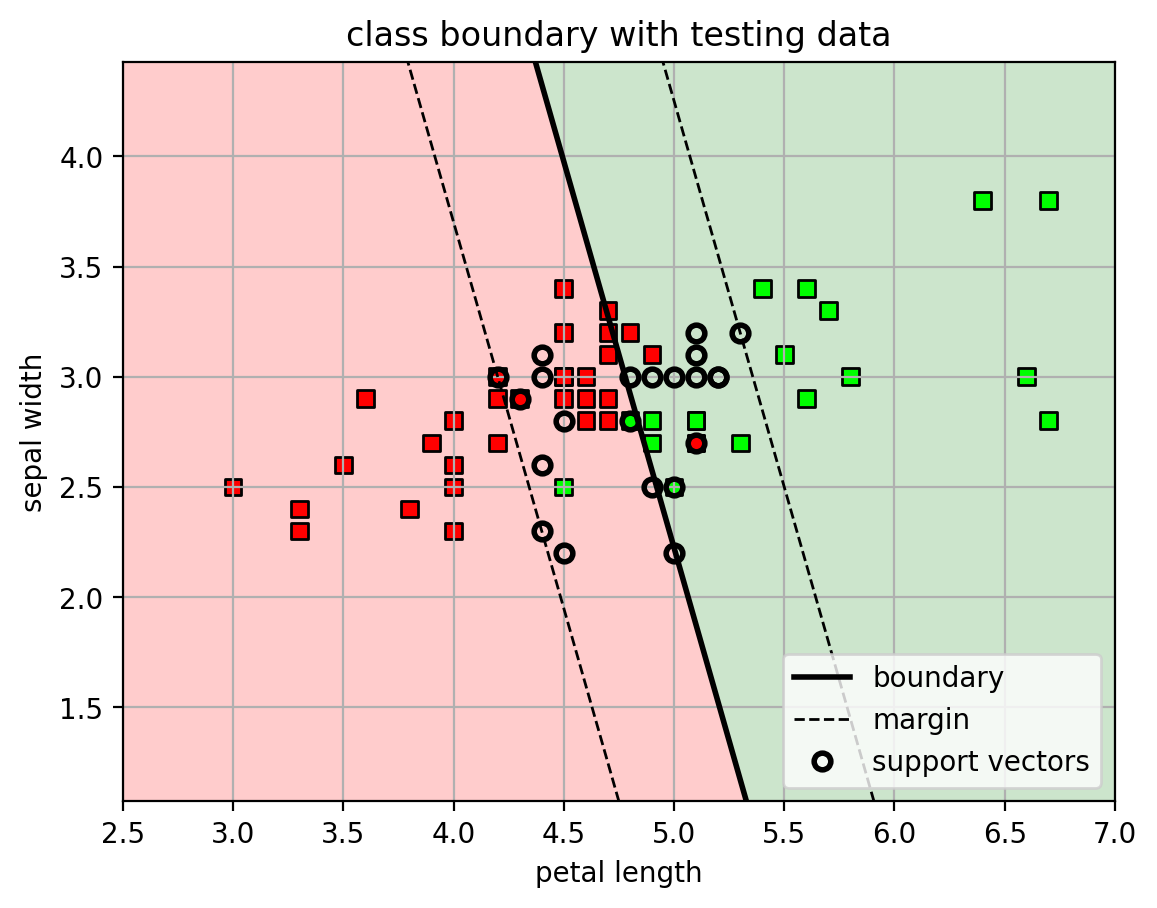

In [41]:
tsvmfig

# Multi-class SVM
- In sklearn, `svm.SVC` implements  "1-vs-1" multi-class classification.
  - Train binary classifiers on all pairs of classes.
    - 3-class Example: 1 vs 2, 1 vs 3, 2 vs 3
  - To label a sample, pick the class with the most votes among the binary classifiers.
- Problem:
  - 1v1 classification is very slow when there are a large number of classes.
    - if there are $C$ classes, need to train $C(C-1)/2$ binary classifiers!

# 1-vs-all SVM
- Use the `multiclass.OneVsRestClassifier` to build a 1-vs-all classifier from any binary classifier.
  - pass it the binary classifier as the base classifier.  
- For `GridSearchCV`, the binary SVM is embedded inside the 1-vs-all wrapper class.
  - use `'estimator__C'` as the parameter label for `C` in the SVM.
  - notation `A__B` means the cross-validated parameter `B` is nested in parameter `A`.
    
<img src="imgs/nestedclassifier.png" width=600>

In [42]:
# load iris data each row is (petal length, sepal width, class)
irisdata = loadtxt('iris3.csv', delimiter=',', skiprows=1)

X = irisdata[:,0:2]  # the first two columns are features (petal length, sepal width)
Y = irisdata[:,2]    # the third column is the class label (setosa=0, versicolor=1, virginica=2)

# randomly split data into 50% train and 50% test set
trainX, testX, trainY, testY = \
  model_selection.train_test_split(X, Y, 
  train_size=0.5, test_size=0.5, random_state=4487)

print(trainX.shape)
print(testX.shape)

(75, 2)
(75, 2)


In [43]:
msvm = multiclass.OneVsRestClassifier(svm.SVC(kernel='linear'))

# setup the parameters and run CV
paramgrid = {'estimator__C': logspace(-3,3,13)}
msvmcv = model_selection.GridSearchCV(msvm, paramgrid, cv=5, n_jobs=-1, verbose=True)
msvmcv.fit(trainX, trainY)
print(msvmcv.best_params_)

Fitting 5 folds for each of 13 candidates, totalling 65 fits
{'estimator__C': np.float64(10.0)}


In [44]:
def plot_posterior3(model, axbox, mycmap, showscore=False):    
    xr = [ arange(0.8,7,0.01) , arange(1.5, 4.5, 0.01) ]
        
    # make a grid for calculating the posterior, 
    #  then form into a big [N,2] matrix
    xgrid0, xgrid1 = meshgrid(xr[0], xr[1])
    allpts = c_[xgrid0.ravel(), xgrid1.ravel()]

    P = model.predict(allpts).reshape(xgrid0.shape)

    # predict probabilities
    if showscore:
        Z = model.decision_function(allpts)

        ZZ = Z.reshape((len(xr[1]), len(xr[0]), 3))
        ZZZ = maximum(minimum(ZZ, 1), -1)/2 + 0.5

        plt.imshow(ZZZ, origin='lower', extent=axbox, alpha=0.50,
                  cmap=mycmap, interpolation='nearest')
    else:
        plt.imshow(P, origin='lower', extent=axbox, alpha=0.50,
               cmap=mycmap, interpolation='nearest')

    #plt.contourf(xr[0], xr[1], P, levels=[0,1,2], cmap=mycmap)
    plt.contour(xr[0], xr[1], P, levels=[0.5,1.5,2.5], linestyles='dashed', colors='black')

# show training data
axbox = [0.8, 7, 1.5, 4.5]
# make a colormap for viewing classes
mycmap = matplotlib.colors.LinearSegmentedColormap.from_list('mycmap', ["#FF0000", "#00FF00", "#0000FF"])

svm3fig = plt.figure()
plot_posterior3(msvmcv, axbox, mycmap)
plt.scatter(trainX[:,0], trainX[:,1], c=trainY, cmap=mycmap, edgecolors='k')
plt.axis(axbox); plt.grid(True);
plt.xlabel('petal length'); plt.ylabel('sepal width')
plt.close()

# 3-class decision boundaries

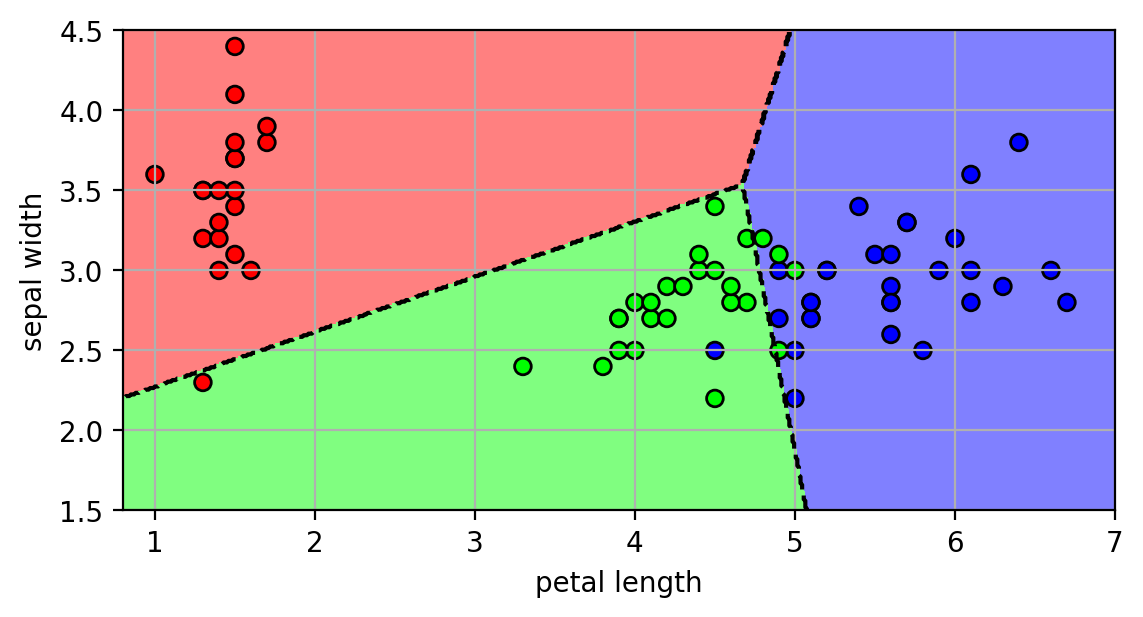

In [45]:
svm3fig

# Non-linear decision boundary
- What if the data is separable, but not linearly separable?

In [46]:
nlfig = plt.figure(figsize=(9,3))
plt.subplot(1,3,1)
# type one - XOR
X1,Y1 = datasets.make_blobs(n_samples=100, 
         centers=array([[5,5],[-5,-5],[-5, 5], [5, -5]]), cluster_std=0.5, n_features=2, 
         random_state=4487)
Y1 = (Y1>=2)+0
plt.scatter(X1[:,0], X1[:,1], c=Y1, cmap=mycmap, edgecolors='k')
plt.xlabel('$x_1$'); plt.ylabel('$x_2$'); plt.grid(True)
plt.gca().xaxis.set_ticklabels([])
plt.gca().yaxis.set_ticklabels([])

# type two - split
X2,Y2 = datasets.make_blobs(n_samples=100, 
         centers=array([[5],[-5],[0]]), cluster_std=0.5, n_features=1, 
         random_state=4487)
Y2 = (Y2>1)+0
plt.subplot(1,3,2)
plt.scatter(X2[:,0], zeros(X2.shape), c=Y2, cmap=mycmap, edgecolors='k')
plt.xlabel('$x$'); plt.grid(True)
plt.gca().xaxis.set_ticklabels([])
plt.gca().yaxis.set_ticklabels([])


# type three - moons
X3,Y3 = datasets.make_moons(n_samples=100,
                                             noise=0.1, random_state=4487)
plt.subplot(1,3,3)
plt.scatter(X3[:,0], X3[:,1], c=Y3, cmap=mycmap, edgecolors='k')
plt.xlabel('$x_1$'); plt.ylabel('$x_2$'); plt.grid(True)
plt.gca().xaxis.set_ticklabels([])
plt.gca().yaxis.set_ticklabels([])
plt.close()

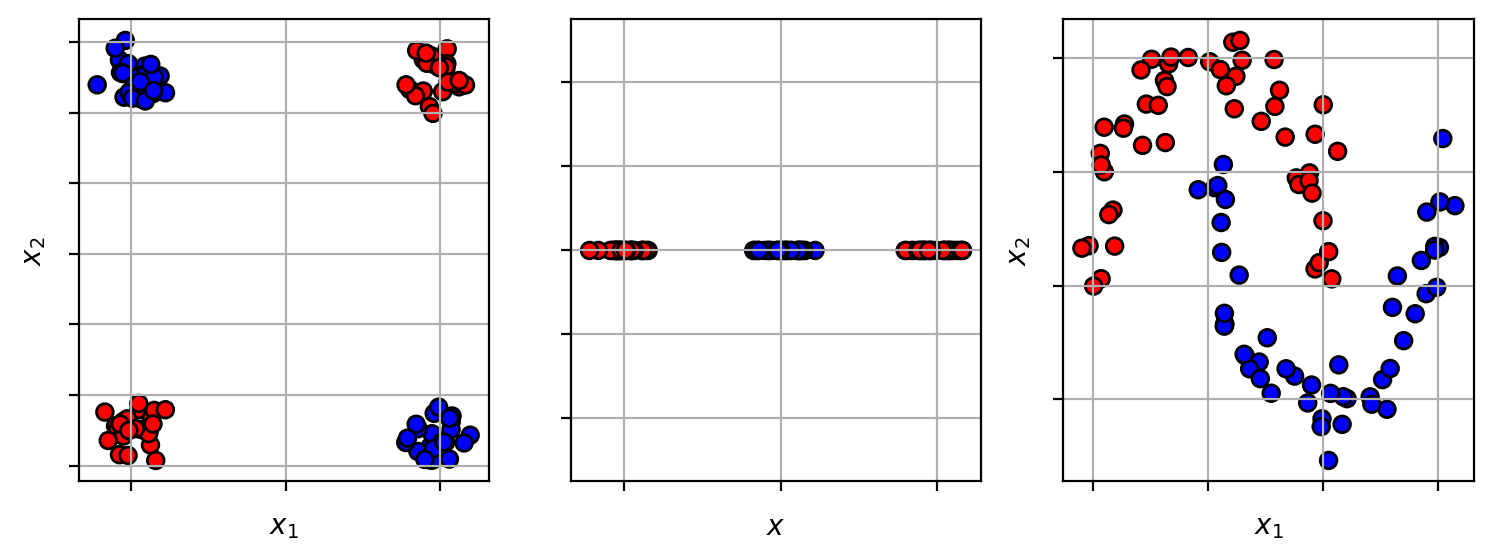

In [47]:
nlfig

# Idea - transform the input space
- map from input space $\mathbf{x} \in \mathbb{R}^d$ to a new high-dimensional space $\mathbf{z} \in \mathbb{R}^D$.
  - $\mathbf{z} = \Phi(\mathbf{x})$, where $\Phi(\mathbf{x})$ is the transformation function.
- learn the linear classifier in the new space
  - if dimension of new space is large enough ($D>d$), then the data should be linearly separable

In [48]:
nl2fig = plt.figure(figsize=(9,7))

# type one - XOR
plt.subplot2grid((5,3),(0,0), rowspan=2)
plt.scatter(X1[:,0], X1[:,1], c=Y1, cmap=mycmap, edgecolors='k')
plt.xlabel('$x_1$'); plt.ylabel('$x_2$'); plt.grid(True)
plt.gca().xaxis.set_ticklabels([])
plt.gca().yaxis.set_ticklabels([])

X1t = X1[:,0]*X1[:,1]

plt.subplot2grid((5,3),(2,0))
plt.annotate("", xy=(0, -1), xytext=(0,0.8), 
             arrowprops=dict(arrowstyle='Fancy,head_width=3,tail_width=2,head_length=2'))
plt.text(0.2,0,"$\Phi(\mathbf{x}) = x_1*x_2$", fontsize=14)
plt.axis([-1, 1, -1, 1])
plt.axis('off')

plt.subplot2grid((5,3),(3,0), rowspan=2)
plt.scatter(X1t, zeros(X1t.shape), c=Y1, cmap=mycmap, edgecolors='k')
plt.xlabel('$x_1 x_2$'); plt.grid(True)
plt.gca().xaxis.set_ticklabels([])
plt.gca().yaxis.set_ticklabels([])
plt.plot([0,0],[-0.5,0.5], 'k-', lw=2)

# type two - split
plt.subplot2grid((5,3),(0,1), rowspan=2)
plt.scatter(X2[:,0], zeros(X2.shape), c=Y2, cmap=mycmap, edgecolors='k')
plt.xlabel('$x$'); plt.grid(True)
plt.gca().xaxis.set_ticklabels([])
plt.gca().yaxis.set_ticklabels([])


plt.subplot2grid((5,3),(2,1))
plt.annotate("", xy=(0, -1), xytext=(0,0.8), 
             arrowprops=dict(arrowstyle='Fancy,head_width=3,tail_width=2,head_length=2'))
plt.text(0.2,0,"$\Phi(\mathbf{x}) = [x, x^2]$", fontsize=14)
plt.axis([-1, 1, -1, 1])
plt.axis('off')


X2t = c_[X2, X2**2]
plt.subplot2grid((5,3),(3,1), rowspan=2)
plt.scatter(X2t[:,0], X2t[:,1], c=Y2, cmap=mycmap, edgecolors='k')
plt.xlabel('$x$'); plt.ylabel('$x^2$');plt.grid(True)
plt.plot([-8,8],[10,10], 'k-', lw=2)
plt.gca().xaxis.set_ticklabels([])
plt.gca().yaxis.set_ticklabels([])

# type three - moons
plt.subplot2grid((5,3),(0,2), rowspan=2)
plt.scatter(X3[:,0], X3[:,1], c=Y3, cmap=mycmap, edgecolors='k')
plt.xlabel('$x_1$'); plt.ylabel('$x_2$'); plt.grid(True)
plt.gca().xaxis.set_ticklabels([])
plt.gca().yaxis.set_ticklabels([])

plt.subplot2grid((5,3),(2,2))
plt.annotate("", xy=(0, -1), xytext=(0,0.8), 
             arrowprops=dict(arrowstyle='Fancy,head_width=3,tail_width=2,head_length=2'))
plt.text(0.2,0,"$\Phi(\mathbf{x})$", fontsize=14)
plt.axis([-1, 1, -1, 1])
plt.axis('off')

plt.subplot2grid((5,3),(3,2), rowspan=2)
plt.arrow(0,0, 10,0, lw=2, head_width=1)
plt.arrow(0,0, 0,10, lw=2, head_width=1)
plt.arrow(0,0, -7,-7, lw=2, head_width=1)

X3t,Y3t = datasets.make_blobs(n_samples=100, 
          centers=array([[-5,5],[5,-5]]), cluster_std=2, n_features=2, 
          random_state=4487)
plt.scatter(X3t[:,0], X3t[:,1], c=Y3t, cmap=mycmap, edgecolors='k')
plt.fill([5, -5, -5, 5], [10, 2, -7, 1], alpha=0.5, color='gray', ls='solid')
plt.axis([-10, 12, -10, 12])
plt.text(-10,-12,"high-dimensional features space")
plt.axis('off')

plt.close()

<>:15: SyntaxWarning: invalid escape sequence '\P'
<>:37: SyntaxWarning: invalid escape sequence '\P'
<>:60: SyntaxWarning: invalid escape sequence '\P'
<>:15: SyntaxWarning: invalid escape sequence '\P'
<>:37: SyntaxWarning: invalid escape sequence '\P'
<>:60: SyntaxWarning: invalid escape sequence '\P'
/var/folders/5h/9z8cfrvj02324js7fw73_cb00000gn/T/ipykernel_43322/1394572907.py:15: SyntaxWarning: invalid escape sequence '\P'
  plt.text(0.2,0,"$\Phi(\mathbf{x}) = x_1*x_2$", fontsize=14)
/var/folders/5h/9z8cfrvj02324js7fw73_cb00000gn/T/ipykernel_43322/1394572907.py:37: SyntaxWarning: invalid escape sequence '\P'
  plt.text(0.2,0,"$\Phi(\mathbf{x}) = [x, x^2]$", fontsize=14)
/var/folders/5h/9z8cfrvj02324js7fw73_cb00000gn/T/ipykernel_43322/1394572907.py:60: SyntaxWarning: invalid escape sequence '\P'
  plt.text(0.2,0,"$\Phi(\mathbf{x})$", fontsize=14)


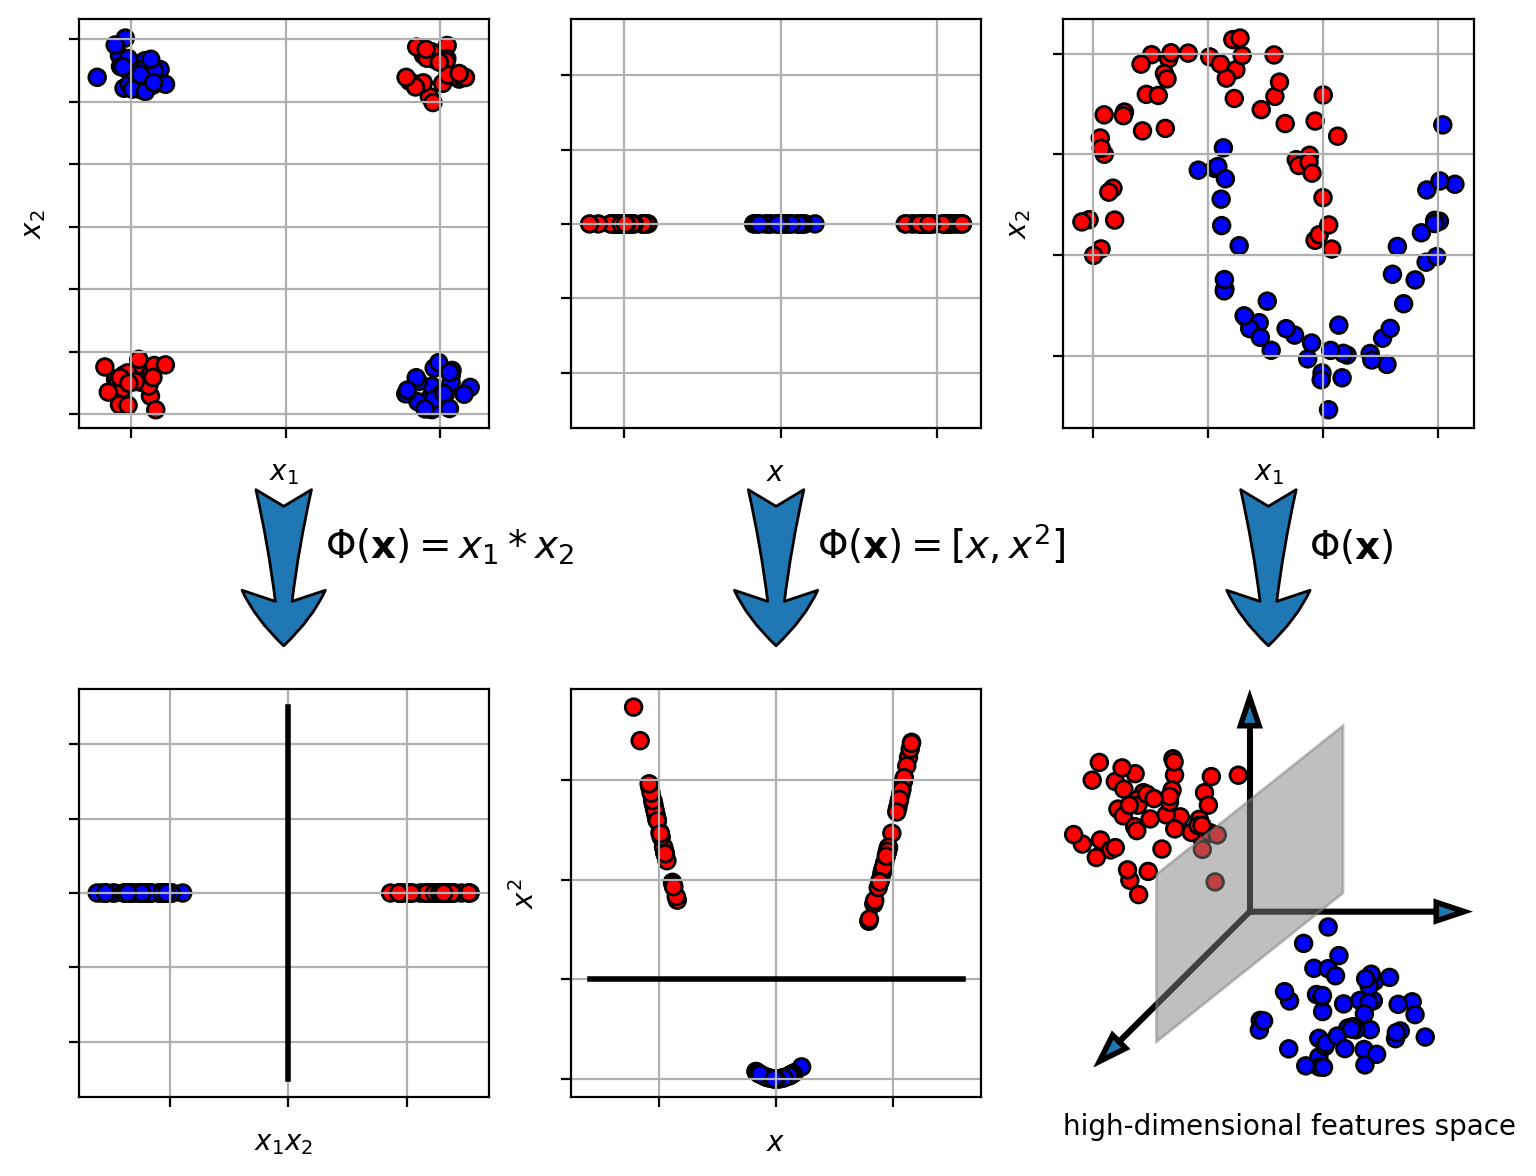

In [49]:
nl2fig

# Kernel function
- the SVM dual problem is completely written in terms of _inner product_ between the high-dimensional feature vectors: $\Phi(\mathbf{x}_i)^T \Phi(\mathbf{x}_j)$
- So rather than explicitly calculate the high-dimensional vector $\Phi(\mathbf{x}_i)$, 
  - we only need to calculate the inner product between two high-dim feature vectors.
- We call this a **kernel function**
  - $k(\mathbf{x}_i, \mathbf{x}_j) = \Phi(\mathbf{x}_i)^T \Phi(\mathbf{x}_j)$
  - calculating the kernel will be less expensive than explicitly calculating the high-dimensional feature vector and the inner product.

# Example: Polynomial kernel
- input vector $\mathbf{x}=\left[\begin{matrix}x_1\\\vdots\\x_d\end{matrix}\right]\in\mathbb{R}^d$
- kernel between two vectors is a $p$-th order polynomial:
  - $k(\mathbf{x},\mathbf{x}') = (\mathbf{x}^T\mathbf{x}')^p = (\sum_{i=1}^d x_i x_i')^p$

- For example, $p=2$,
  $$\begin{align}k(\mathbf{x},\mathbf{x}') &= (\mathbf{x}^T \mathbf{x}')^2 = (\sum_{i=1}^d x_i x_i')^2 \\ &= \sum_{i=1}^d \sum_{j=1}^d (x_ix_i' x_jx_j') = \Phi(\mathbf{x})^T \Phi(\mathbf{x}')\end{align}$$
  - transformed feature space is the quadratic terms of the input vector: 
    $$ \Phi(\mathbf{x}) = \left[\begin{matrix} x_1 x_1 \\ x_1 x_2 \\ \vdots  \\
    x_2 x_1 \\x_2 x_2 \\ \vdots \\
    x_d x_1 \\ \vdots \\ x_d x_d
    \end{matrix}\right]
    $$

- Comparison of number of multiplications
  - for kernel: $O(d)$
  - explicit transformation $\Phi$: $O(d^2)$

# Kernel trick
- Replacing the inner product with a kernel function in the optimization problem is called the **kernel trick**.
  - _turns a linear classification algorithm into a non-linear classification algorithm_.
  - the shape of the decision boundary is determined by the kernel.

# Kernel SVM
- Replace inner product in linear SVM with kernel function:
  $$\mathop{\mathrm{argmax}}_{\alpha} \sum_i \alpha_i -\frac{1}{2}\sum_{i=1}^N\sum_{j=1}^N \alpha_i\alpha_j y_i y_j k(\mathbf{x}_i, \mathbf{x}_j) \\~~ \mathrm{s.t.} \sum_{i=1}^N \alpha_iy_i = 0, \quad \alpha_i\geq 0$$
- Prediction
  - $y_* = \mathrm{sign}(\sum_{i=1}^N \alpha_i y_i k(\mathbf{x}_i, \mathbf{x}_*) + b)$

# Example: Kernel SVM with polynomial kernel
- decision surface is a "cut" of a polynomial surface
- higher polynomial-order yields more complex decision boundaries.

In [50]:
inds = (Y3==0)
X4 = X3[inds]
Y4 = Y3[inds]
tmpX,tmpY = datasets.make_blobs(n_samples=20, 
         centers=1, cluster_std=0.2, n_features=2, 
         center_box=(0,0), random_state=4487)
X4 = vstack((X4,tmpX))
Y4 = r_[Y4, tmpY+1]

In [51]:
# fit SVM (poly kernel with different degrees)
degs = [2,3,4]

clf = {}
for d in degs:
    clf[d] = svm.SVC(kernel='poly', degree=d, C=100)
    clf[d].fit(X4, Y4)

In [52]:
def plot_posterior_svm(model, axbox, X, phi=None):
    # grid points
    xr = [ linspace(axbox[0], axbox[1], 200), 
           linspace(axbox[2], axbox[3], 200) ]

    # make a grid for calculating the posterior, 
    #  then form into a big [N,2] matrix
    xgrid0, xgrid1 = meshgrid(xr[0], xr[1])
    allptsx = c_[xgrid0.ravel(), xgrid1.ravel()]

    # transform
    if phi != None:
        allpts = apply_along_axis(phi, 1, allptsx)
    else:
        allpts = allptsx
    
    # calculate the score
    score = model.decision_function(allpts).reshape(xgrid0.shape)

    cmap = ([1,0,0], [1,0.7,0.7], [0.7,1,0.7], [0,1,0])
    CS = plt.contourf(xr[0], xr[1], score, colors=cmap, 
                      levels=[-1000, -1, 0, 1, 1000], alpha=0.3)

    plt.contour(xr[0], xr[1], score, levels=[-1, 1], linewidths=1, linestyles='dashed', colors='k')
    plt.contour(xr[0], xr[1], score, levels=[0], linestyles='solid', colors='k')
        
    plt.plot([-100,-100], [-100,-100], 'k-', label='boundary')
    plt.plot([-100,-100], [-100,-100], 'k--', label='margin')
    
    plt.plot(X[model.support_,0], X[model.support_,1], 
             'ko',fillstyle='none', markeredgewidth=2, label='support vectors')

    leg = plt.legend(loc='best', fontsize=7)
    leg.get_frame().set_facecolor('white')         
    plt.axis(axbox); plt.grid(True)    

In [53]:
axbox = [-1.5, 1.5, -1.5, 1.5]

polysvmfig = plt.figure(figsize=(9,3))

for (i,d) in enumerate(degs):
    plt.subplot(1,3,i+1)
    plot_posterior_svm(clf[d], axbox, X4)
    plt.scatter(X4[:,0], X4[:,1], c=Y4, cmap=mycmap, edgecolors='k')
    plt.xlabel('$x_1$'); plt.ylabel('$x_2$')
    plt.gca().xaxis.set_ticklabels([])
    plt.gca().yaxis.set_ticklabels([])    
    plt.title('polynomial deg=' + str(degs[i]))
plt.close()

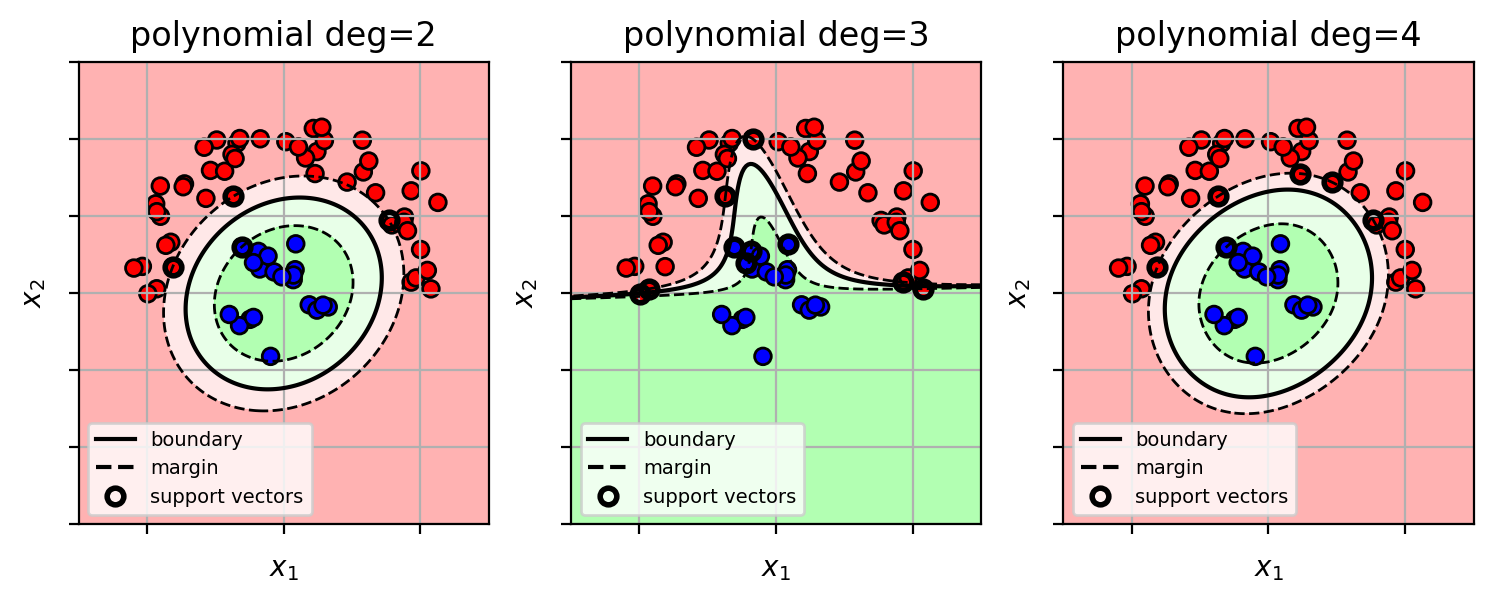

In [54]:
polysvmfig

# RBF kernel
- RBF kernel (radial basis function)
  - $k(\mathbf{x},\mathbf{x}') = e^{-\gamma\|\mathbf{x}-\mathbf{x}'\|^2}$
  - similar to a Gaussian
- gamma $\gamma>0$ is the inverse bandwidth parameter of the kernel
  - controls the smoothness of the function
  - small $\gamma$ &#8594; wider RBF &#8594; smooth functions
  - large $\gamma$ &#8594; thin RBF &#8594; wiggly function

In [55]:
rbffig = plt.figure()
x = linspace(-10,10,500)
gammas = array([0.1, 1.0, 10.0])
for g in gammas:
    kx = exp(-g*(x**2))
    plt.plot(x, kx, label="$\gamma="+str(g)+"$")
plt.xlabel("$||\mathbf{x}-\mathbf{x}'||$")
plt.ylabel("$k(\mathbf{x},\mathbf{x}')$")
plt.axis([-10, 10, 0, 1.1]); plt.grid(True)
plt.legend()
plt.close()

<>:6: SyntaxWarning: invalid escape sequence '\g'
<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\g'
<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
/var/folders/5h/9z8cfrvj02324js7fw73_cb00000gn/T/ipykernel_43322/1872335391.py:6: SyntaxWarning: invalid escape sequence '\g'
  plt.plot(x, kx, label="$\gamma="+str(g)+"$")
/var/folders/5h/9z8cfrvj02324js7fw73_cb00000gn/T/ipykernel_43322/1872335391.py:7: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("$||\mathbf{x}-\mathbf{x}'||$")
/var/folders/5h/9z8cfrvj02324js7fw73_cb00000gn/T/ipykernel_43322/1872335391.py:8: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$k(\mathbf{x},\mathbf{x}')$")


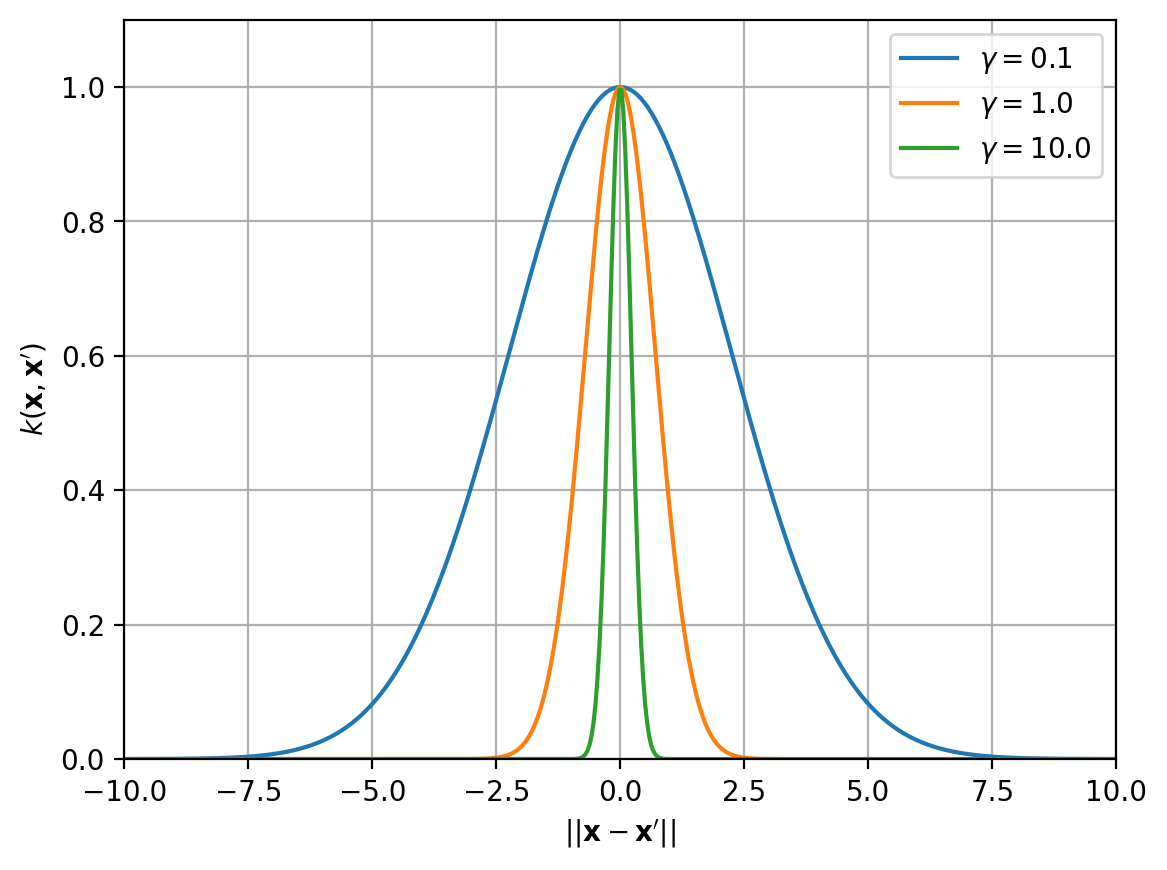

In [56]:
rbffig

# Kernel SVM with RBF kernel
- try different $\gamma$
  - each $\gamma$ yields different levels of smoothness of the decision boundary

In [57]:
# fit SVM (RBF)
gammas = [0.1, 1, 25]

clf = {}
for i in gammas:
    clf[i] = svm.SVC(kernel='rbf', gamma=i, C=1000)
    clf[i].fit(X3, Y3)

In [58]:
axbox = [-2, 3, -2, 2]

rbfsvmfig = plt.figure(figsize=(9,3))

for i,x in enumerate(gammas):
    clfx = clf[x]
    plt.subplot(1,3,i+1)

    plot_posterior_svm(clfx, axbox, X3)
    plt.scatter(X3[:,0], X3[:,1], c=Y3, cmap=mycmap, edgecolors='k')
    plt.xlabel('$x_1$'); plt.ylabel('$x_2$')
    plt.gca().xaxis.set_ticklabels([])
    plt.gca().yaxis.set_ticklabels([])
    plt.title('RBF $\gamma$=' + str(x))
plt.close()

<>:14: SyntaxWarning: invalid escape sequence '\g'
<>:14: SyntaxWarning: invalid escape sequence '\g'
/var/folders/5h/9z8cfrvj02324js7fw73_cb00000gn/T/ipykernel_43322/1549002258.py:14: SyntaxWarning: invalid escape sequence '\g'
  plt.title('RBF $\gamma$=' + str(x))


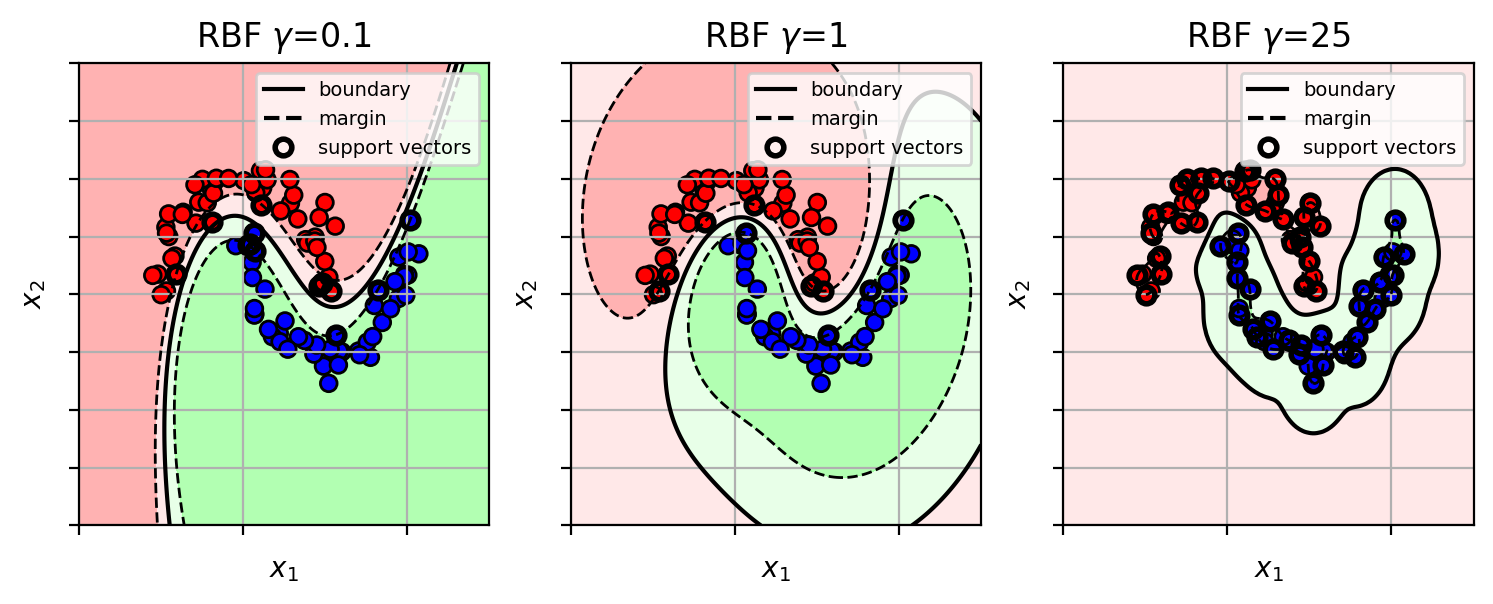

In [59]:
rbfsvmfig

# Example on Iris data
- Large $\gamma$ yields a complicated wiggly decision boundary.

In [60]:
# load iris data each row is (petal length, sepal width, class)
irisdata = loadtxt('iris2.csv', delimiter=',', skiprows=1)

X = irisdata[:,0:2]  # the first two columns are features (petal length, sepal width)
Y = irisdata[:,2]    # the third column is the class label (versicolor=1, virginica=2)

print(X.shape)

(100, 2)


In [61]:
# randomly split data into 50% train and 50% test set
trainX, testX, trainY, testY = \
  model_selection.train_test_split(X, Y, 
  train_size=0.5, test_size=0.5, random_state=4487)

print(trainX.shape)
print(testX.shape)

(50, 2)
(50, 2)


In [62]:
# fit SVM (RBF)
gammas = [0.1, 1, 10]

clf = {}
for i in gammas:
    clf[i] = svm.SVC(kernel='rbf', gamma=i, C=100)
    clf[i].fit(trainX, trainY)

irbffig = plt.figure(figsize=(9,3))
axbox = [2.5, 7, 1.5, 4]
for i,x in enumerate(gammas):
    plt.subplot(1,3,i+1)
    plot_posterior_svm(clf[x], axbox, trainX)
    plt.scatter(trainX[:,0],trainX[:,1],c=trainY, cmap=mycmap, edgecolors='k')
    plt.xlabel('petal length'); plt.ylabel('sepal width')
    plt.gca().xaxis.set_ticklabels([])
    plt.gca().yaxis.set_ticklabels([])
    plt.title('RBF $\gamma$=' + str(x))
plt.close()

<>:18: SyntaxWarning: invalid escape sequence '\g'
<>:18: SyntaxWarning: invalid escape sequence '\g'
/var/folders/5h/9z8cfrvj02324js7fw73_cb00000gn/T/ipykernel_43322/263472167.py:18: SyntaxWarning: invalid escape sequence '\g'
  plt.title('RBF $\gamma$=' + str(x))


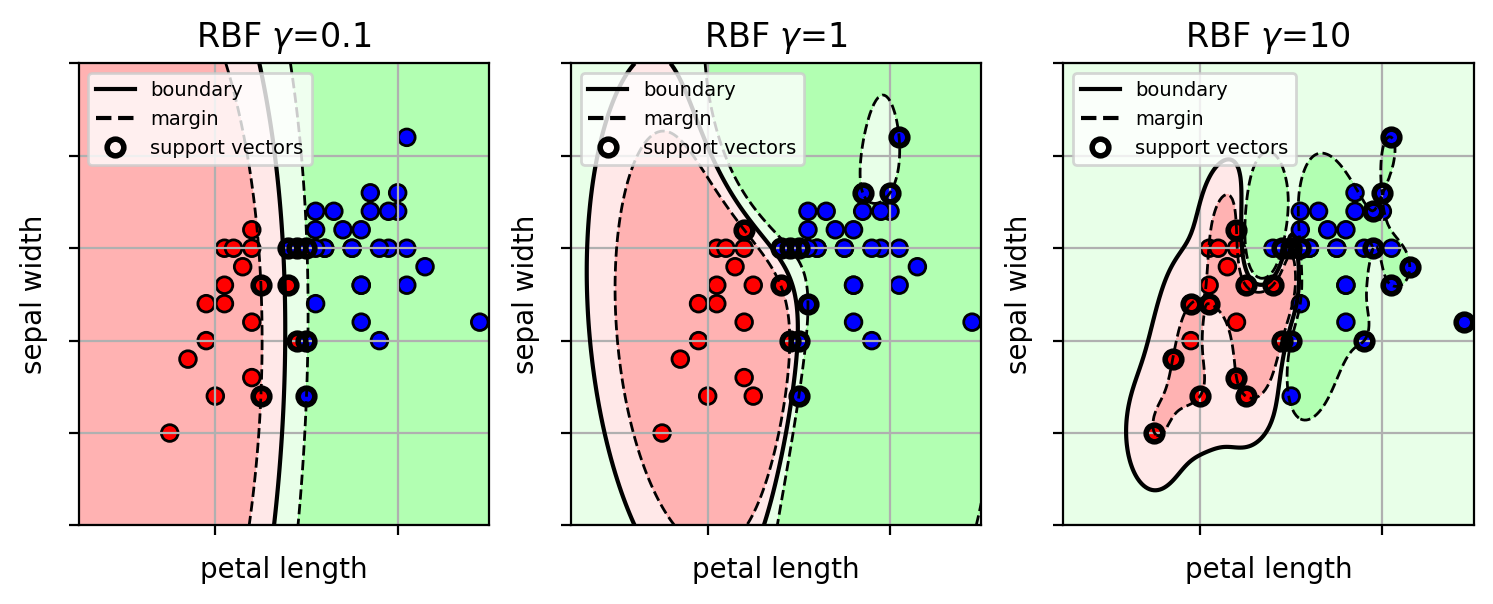

In [63]:
irbffig

# How to select the best kernel parameters?
- use cross-validation over possible kernel parameter ($\gamma$) and SVM $C$ parameter
  - if a lot of parameters, can be computationally expensive!

In [64]:
# setup the list of parameters to try
paramgrid = {'C': logspace(-2,3,20), 
             'gamma': logspace(-4,3,20) }

print(paramgrid)

# setup the cross-validation object
# pass the SVM object w/ rbf kernel, parameter grid, and number of CV folds
svmcv = model_selection.GridSearchCV(svm.SVC(kernel='rbf'), paramgrid, cv=5,
                                    n_jobs=-1, verbose=True)

# run cross-validation (train for each split)
svmcv.fit(trainX, trainY);

print("best params:", svmcv.best_params_)

{'C': array([1.00000000e-02, 1.83298071e-02, 3.35981829e-02, 6.15848211e-02,
       1.12883789e-01, 2.06913808e-01, 3.79269019e-01, 6.95192796e-01,
       1.27427499e+00, 2.33572147e+00, 4.28133240e+00, 7.84759970e+00,
       1.43844989e+01, 2.63665090e+01, 4.83293024e+01, 8.85866790e+01,
       1.62377674e+02, 2.97635144e+02, 5.45559478e+02, 1.00000000e+03]), 'gamma': array([1.00000000e-04, 2.33572147e-04, 5.45559478e-04, 1.27427499e-03,
       2.97635144e-03, 6.95192796e-03, 1.62377674e-02, 3.79269019e-02,
       8.85866790e-02, 2.06913808e-01, 4.83293024e-01, 1.12883789e+00,
       2.63665090e+00, 6.15848211e+00, 1.43844989e+01, 3.35981829e+01,
       7.84759970e+01, 1.83298071e+02, 4.28133240e+02, 1.00000000e+03])}
Fitting 5 folds for each of 400 candidates, totalling 2000 fits
best params: {'C': np.float64(0.37926901907322497), 'gamma': np.float64(0.4832930238571752)}


In [65]:
# show the test error for the first 25 parameter sets
N = 25
for m,p in zip(svmcv.cv_results_['mean_test_score'][0:N], svmcv.cv_results_['params'][0:N]):
    print("mean={:.4f} {}".format(m,p))

mean=0.6200 {'C': np.float64(0.01), 'gamma': np.float64(0.0001)}
mean=0.6200 {'C': np.float64(0.01), 'gamma': np.float64(0.00023357214690901214)}
mean=0.6200 {'C': np.float64(0.01), 'gamma': np.float64(0.000545559478116852)}
mean=0.6200 {'C': np.float64(0.01), 'gamma': np.float64(0.0012742749857031334)}
mean=0.6200 {'C': np.float64(0.01), 'gamma': np.float64(0.002976351441631319)}
mean=0.6200 {'C': np.float64(0.01), 'gamma': np.float64(0.0069519279617756054)}
mean=0.6200 {'C': np.float64(0.01), 'gamma': np.float64(0.01623776739188721)}
mean=0.6200 {'C': np.float64(0.01), 'gamma': np.float64(0.0379269019073225)}
mean=0.6200 {'C': np.float64(0.01), 'gamma': np.float64(0.08858667904100823)}
mean=0.6200 {'C': np.float64(0.01), 'gamma': np.float64(0.2069138081114788)}
mean=0.6200 {'C': np.float64(0.01), 'gamma': np.float64(0.4832930238571752)}
mean=0.6200 {'C': np.float64(0.01), 'gamma': np.float64(1.1288378916846884)}
mean=0.6200 {'C': np.float64(0.01), 'gamma': np.float64(2.63665089873035

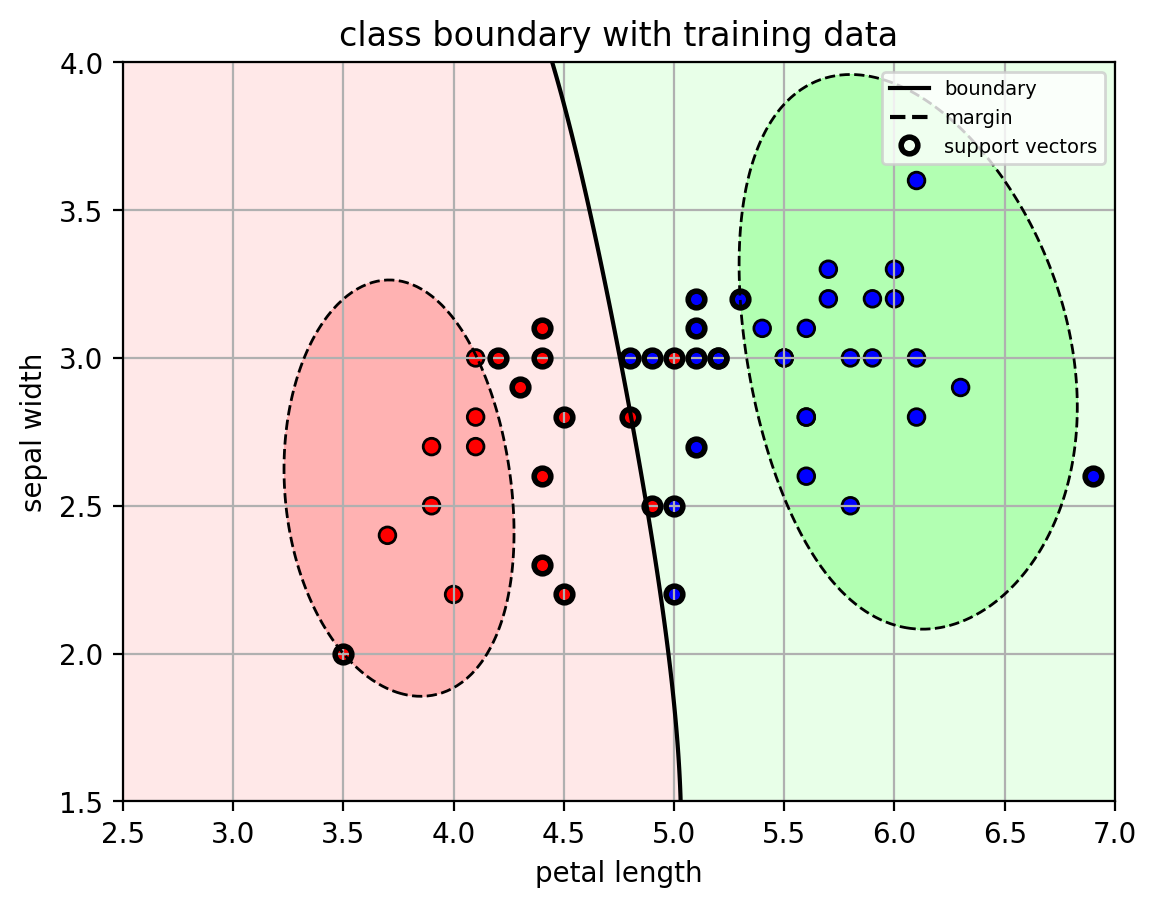

In [66]:
# show classifier with training data
plt.figure()
plot_posterior_svm(svmcv.best_estimator_, axbox, trainX)
plt.scatter(trainX[:,0], trainX[:,1], c=trainY, cmap=mycmap, edgecolors='k')
plt.xlabel('petal length'); plt.ylabel('sepal width')
plt.title('class boundary with training data');
plt.show()

In [67]:
# predict from the model
predY = svmcv.predict(testX)

# calculate accuracy
acc      = metrics.accuracy_score(testY, predY)
print("test accuracy =", acc)

test accuracy = 0.88


# Custom kernel function
- we can use any kernel function, as long as it is *positive semi-definite*:
  - 1) it can be written as an inner-product of a feature transformation: $k(\mathbf{x}_1,\mathbf{x}_2) = \langle \Phi(\mathbf{x}_1), \Phi(\mathbf{x}_2) \rangle$.
  - 2) for all possible datasets $\mathbf{X} = \{\mathbf{x}_1, \cdots \mathbf{x}_N\}$ of all possible sizes $N$, the kernel matrix $K=[k(\mathbf{x}_i,\mathbf{x}_j)]_{i,j}$ is a positive definite matrix.
    - $\mathbf{K}$ is a *positive semi-definite matrix* iff $\mathbf{z}^T\mathbf{K}\mathbf{z} \geq 0, \forall \mathbf{z}$
- in sklearn, pass a callable function as the kernel parameter.

## Example: Laplacian kernel
- $k(\mathbf{x}_1,\mathbf{x}_2) = \exp(-\alpha ||\mathbf{x}_1 - \mathbf{x}_2||)$

In [68]:
from scipy import spatial

# create a custom kernel function
# Laplacian kernel: exp( -alpha*||x1-x2|| )
def mykernel(X1, X2, alpha=1.0):
    # X1,X2 are (N1 x d) and (N2 x d) matrices of N1 and N2 d-dim vectors
    # alpha is the hyperparameter
    
    # compute pairwise euclidean distance
    D = spatial.distance.cdist(X1, X2, metric='euclidean')
    
    # return the kernel matrix
    return exp(-alpha*D)

In [69]:
alphas = [0.1, 1., 10.]

clf = {}
for i in alphas:
    # make a temporary kernel function with the selected alpha value
    tmpkern = lambda X1,X2,alpha=i: mykernel(X1,X2,alpha=alpha)
    
    # create the SVM with custom kernel function
    clf[i] = svm.SVC(kernel=tmpkern, C=100)
    clf[i].fit(trainX, trainY)

In [70]:
ilapfig = plt.figure(figsize=(9,3))
axbox = [2.5, 7, 1.5, 4]
for i,x in enumerate(alphas):
    plt.subplot(1,3,i+1)
    plot_posterior_svm(clf[x], axbox, trainX)
    plt.scatter(trainX[:,0],trainX[:,1],c=trainY, cmap=mycmap, edgecolors='k')
    plt.xlabel('petal length'); plt.ylabel('sepal width')
    plt.gca().xaxis.set_ticklabels([])
    plt.gca().yaxis.set_ticklabels([])
    plt.title('Laplacian $\\alpha$=' + str(x))
plt.close()

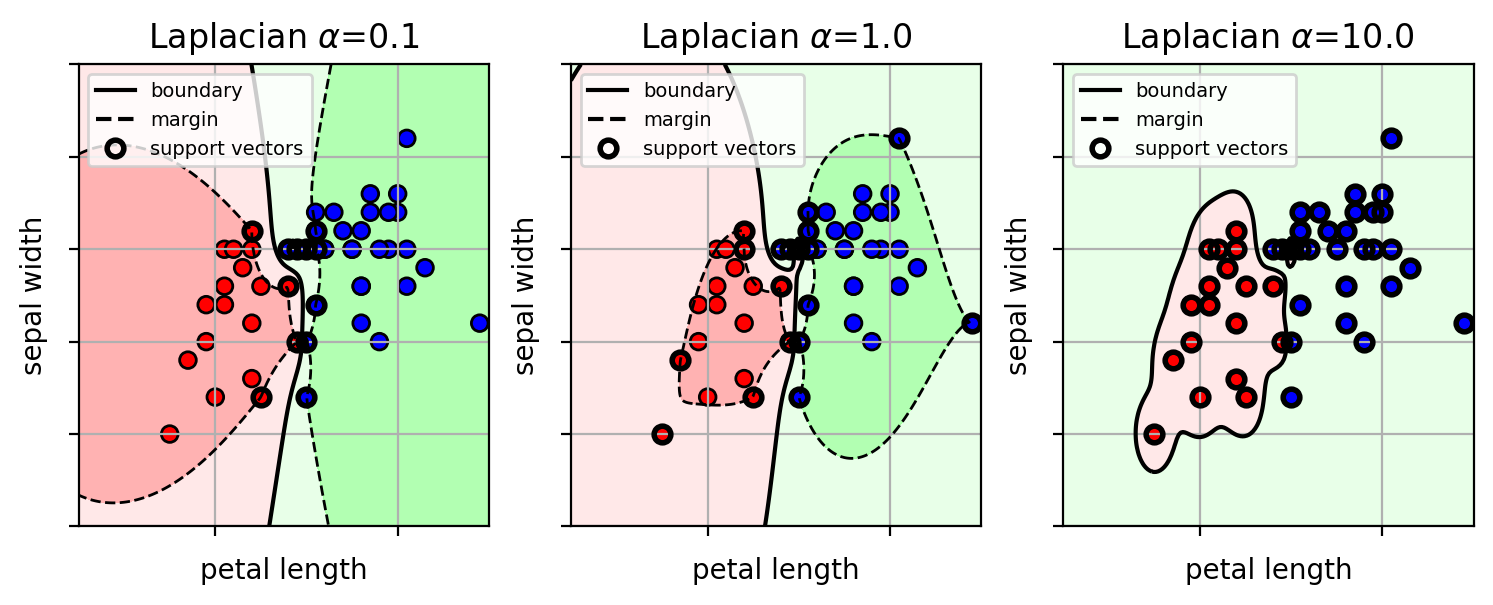

In [71]:
ilapfig

# SVM Summary
- **Linear SVM:**
  - linear function $f(\mathbf{x}) = \mathbf{w}^T\mathbf{x} + b$
  - given new sample $\mathbf{x}_*$, predict $y_* = \mathrm{sign}(f(\mathbf{x}_*))$.
- **Kernel SVM:**
  - Kernel function defines the shape of the non-linear decision boundary.
    - implicitly transforms input feature into high-dimensional space.
    - uses linear classifier in high-dim space.
    - the decision boundary is non-linear in the original input space.
- **Training:**
  - Maximize the margin of the training data.
    - i.e., maximize the separation between the points and the decision boundary.
  - Use cross-validation to pick the hyperparameter $C$ and the kernel hyperparameters.